2024-07-26 14:28:56.061004: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-26 14:28:56.207640: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-07-26 14:28:56.207667: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2024-07-26 14:28:56.238395: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-26 14:28:57.189805: W tensorflow/stream_executor/pla

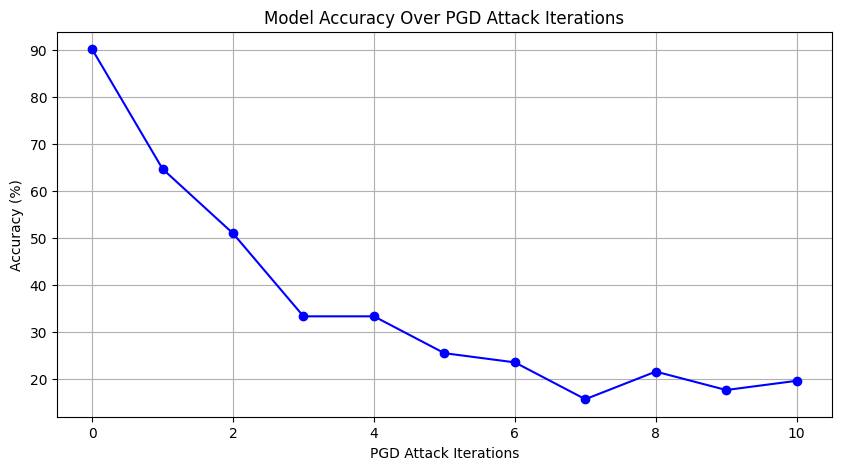

10512/10512 [==============================] - 13s 1ms/step


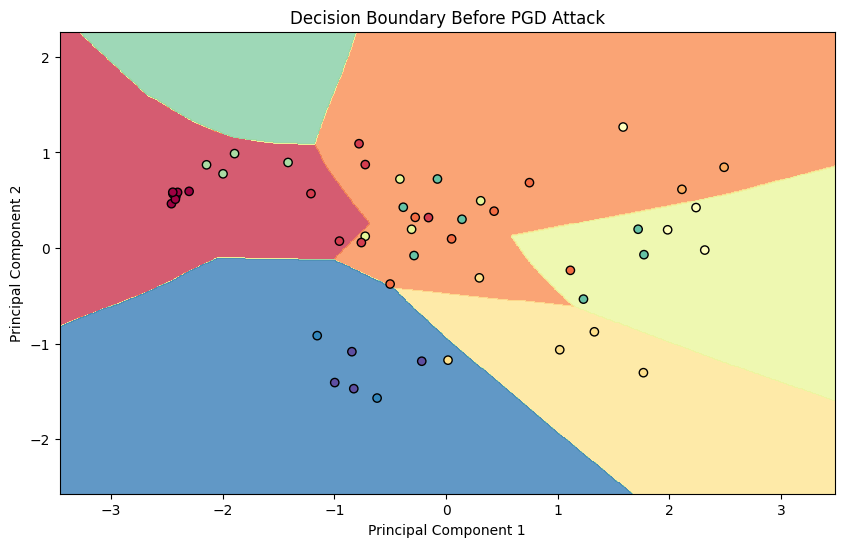

6788/6788 [==============================] - 9s 1ms/step


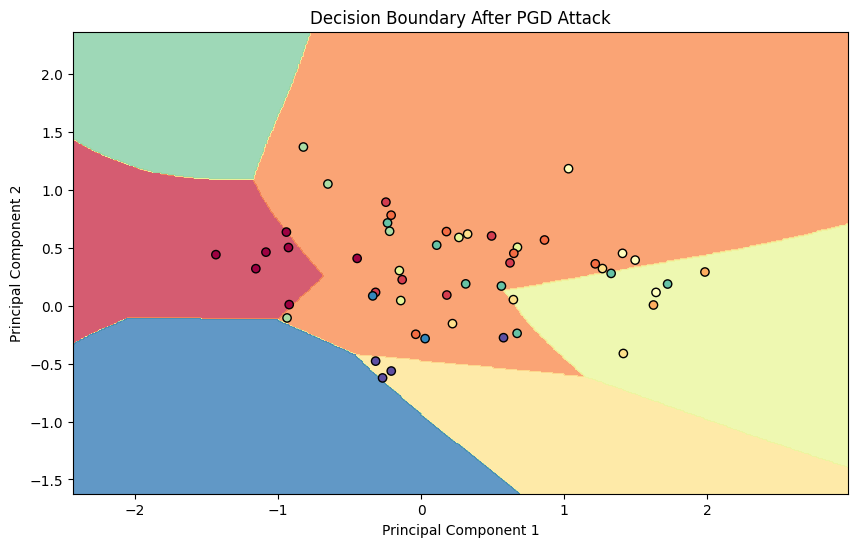

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize the PGD attack
attack = ProjectedGradientDescent(estimator=classifier, eps=0.1, eps_step=0.01, max_iter=10)

# Generate adversarial test examples iteratively and track accuracy
accuracies = [accuracy_before_attack * 100]
X_test_adv = X_test.copy()

for i in range(1, attack.max_iter + 1):
    X_test_adv = attack.generate(X_test_adv)
    loss, accuracy = model.evaluate(X_test_adv, y_test, verbose=0)
    accuracies.append(accuracy * 100)
    print(f"Accuracy at iteration {i}: {accuracy*100:.2f}%")

# Plot model accuracy over PGD attack iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('PGD Attack Iterations')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Over PGD Attack Iterations')
plt.grid(True)
plt.show()

# Plot decision boundaries before and after attack
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

# Apply PCA to adversarial examples at the last iteration
X_test_adv_pca = pca.transform(X_test_adv)

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before PGD Attack')
plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After PGD Attack')


Epoch 1/10
21/21 [==============================] - 1s 5ms/step - loss: 2.3202 - accuracy: 0.1891
Epoch 2/10
21/21 [==============================] - 0s 5ms/step - loss: 1.9298 - accuracy: 0.5970
Epoch 3/10
21/21 [==============================] - 0s 6ms/step - loss: 1.5000 - accuracy: 0.8408
Epoch 4/10
21/21 [==============================] - 0s 4ms/step - loss: 1.0666 - accuracy: 0.9204
Epoch 5/10
21/21 [==============================] - 0s 2ms/step - loss: 0.7096 - accuracy: 0.9453
Epoch 6/10
21/21 [==============================] - 0s 4ms/step - loss: 0.4830 - accuracy: 0.9602
Epoch 7/10
21/21 [==============================] - 0s 3ms/step - loss: 0.3429 - accuracy: 0.9751
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.2393 - accuracy: 0.9801
Epoch 9/10
21/21 [==============================] - 0s 3ms/step - loss: 0.1797 - accuracy: 0.9900
Epoch 10/10
21/21 [==============================] - 0s 4ms/step - loss: 0.1363 - accuracy: 0.9900
Accuracy before att

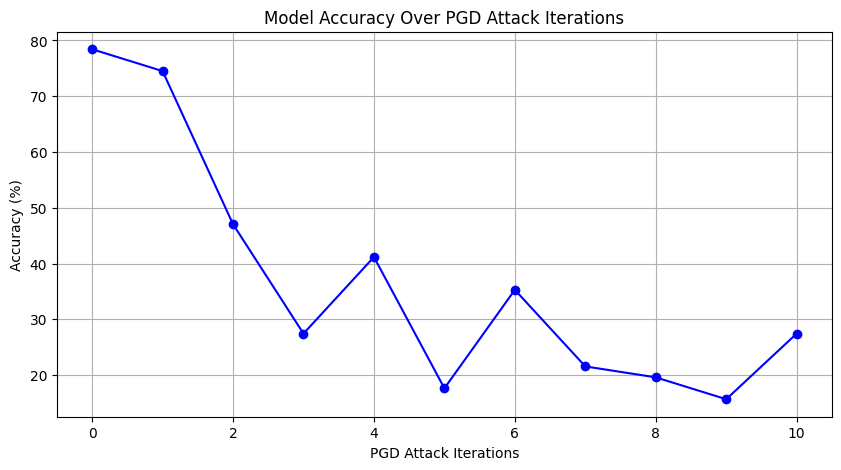

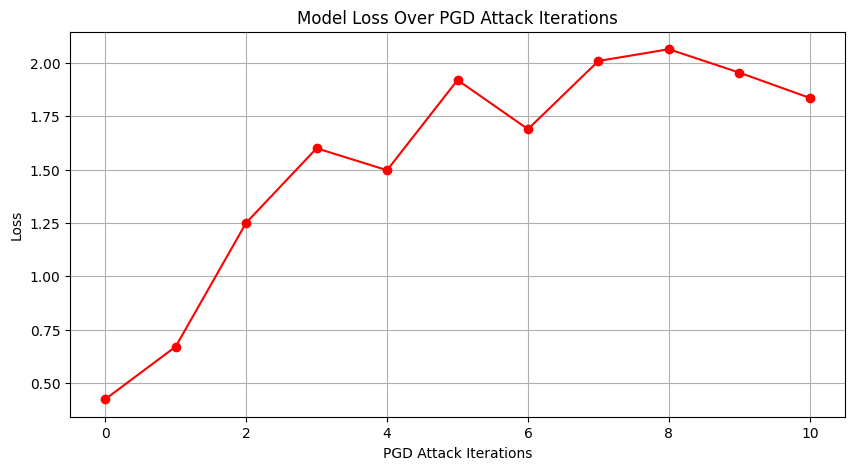

2/2 [==============================] - 0s 16ms/step


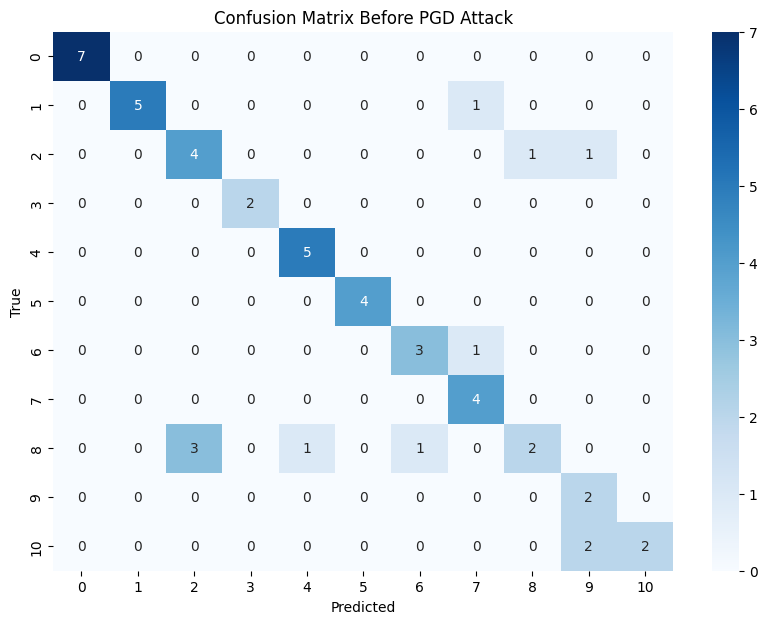

2/2 [==============================] - 0s 5ms/step


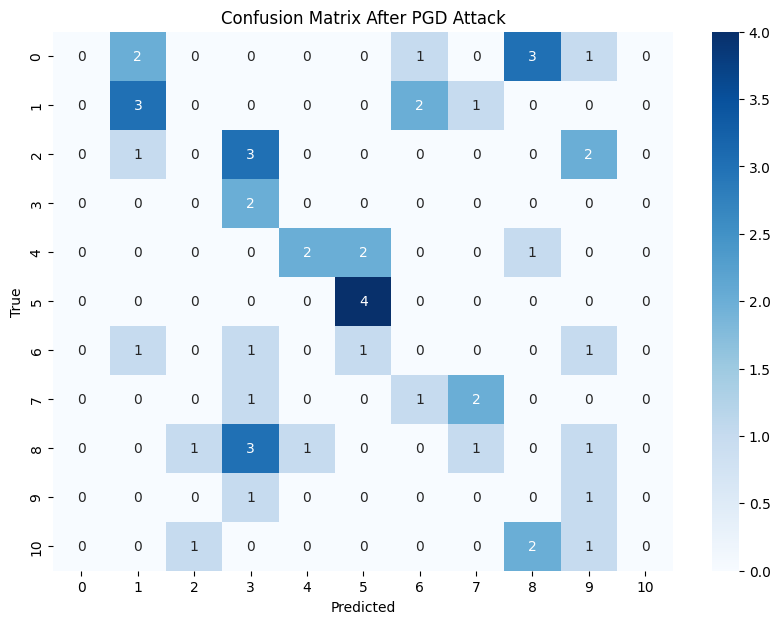

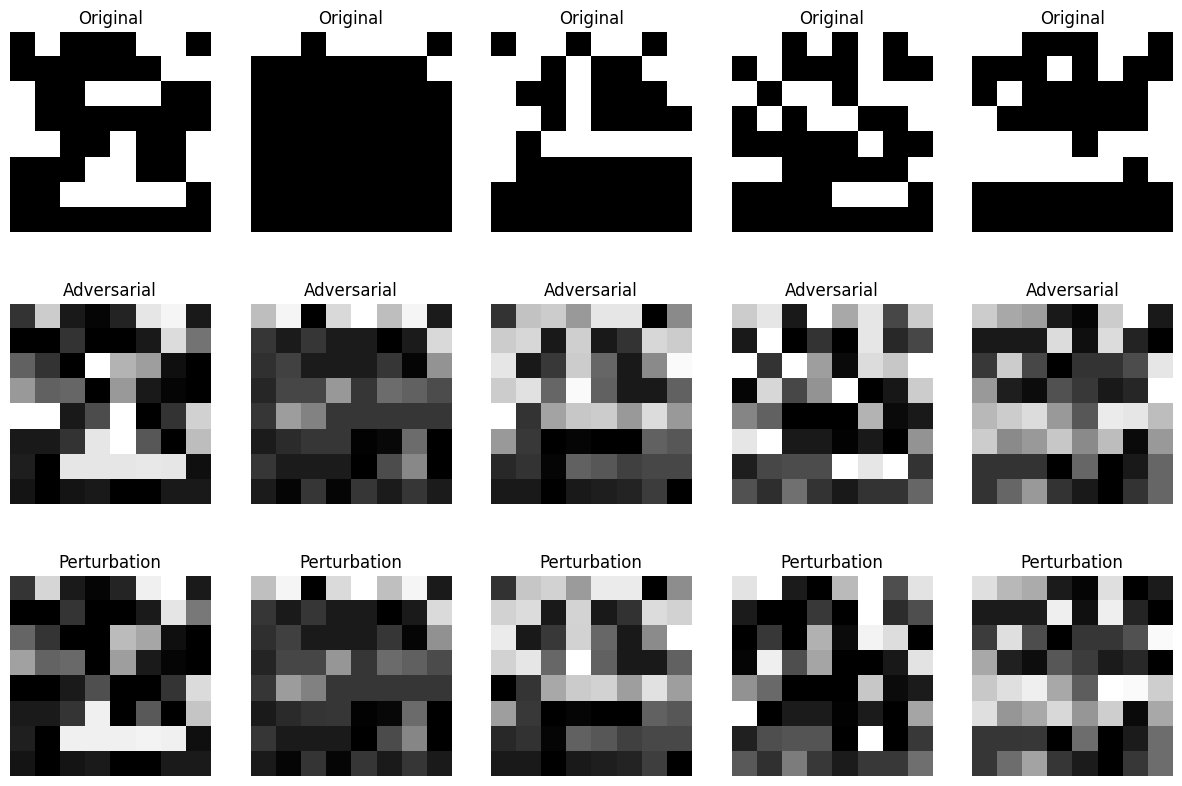

10512/10512 [==============================] - 21s 2ms/step


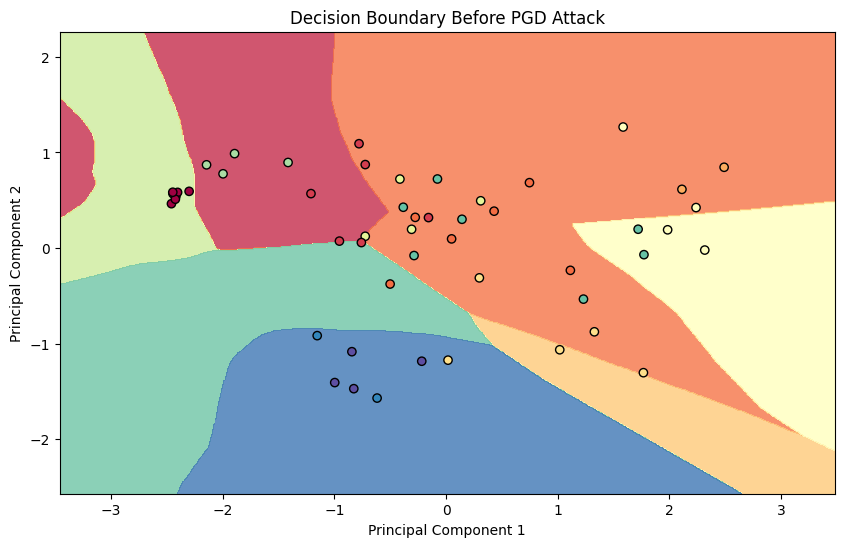

6608/6608 [==============================] - 13s 2ms/step


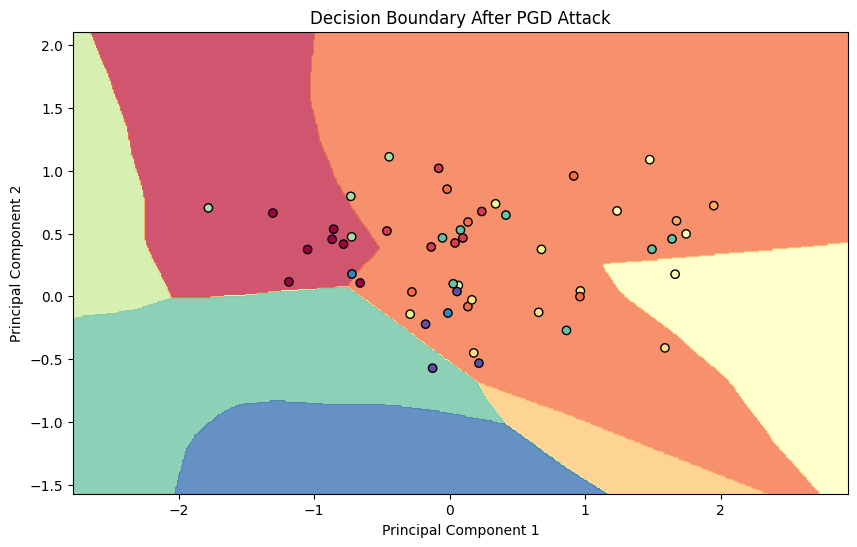

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize the PGD attack
attack = ProjectedGradientDescent(estimator=classifier, eps=0.1, eps_step=0.01, max_iter=10)

# Generate adversarial test examples iteratively and track accuracy
losses = [loss]
accuracies = [accuracy_before_attack * 100]
X_test_adv = X_test.copy()

for i in range(1, attack.max_iter + 1):
    X_test_adv = attack.generate(X_test_adv)
    loss, accuracy = model.evaluate(X_test_adv, y_test, verbose=0)
    losses.append(loss)
    accuracies.append(accuracy * 100)
    print(f"Loss at iteration {i}: {loss:.4f}, Accuracy: {accuracy*100:.2f}%")

# Plot model accuracy over PGD attack iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('PGD Attack Iterations')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Over PGD Attack Iterations')
plt.grid(True)
plt.show()

# Plot model loss over PGD attack iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), losses, marker='o', linestyle='-', color='r')
plt.xlabel('PGD Attack Iterations')
plt.ylabel('Loss')
plt.title('Model Loss Over PGD Attack Iterations')
plt.grid(True)
plt.show()

# Plot confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before PGD Attack')
plt.show()

# Plot confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After PGD Attack')
plt.show()

# Visualize perturbations
perturbations = X_test_adv - X_test
num_samples = 5  # Number of samples to visualize

plt.figure(figsize=(15, 10))
for i in range(num_samples):
    plt.subplot(3, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(3, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')

    plt.subplot(3, num_samples, i+1+2*num_samples)
    plt.imshow((perturbations[i] * 255).astype(np.uint8).reshape((8, 8)), cmap='gray')
    plt.title('Perturbation')
    plt.axis('off')
plt.show()

# Plot decision boundaries before and after attack
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

# Apply PCA to adversarial examples at the last iteration
X_test_adv_pca = pca.transform(X_test_adv)

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before PGD Attack')
plot_decision_boundary(X_test_adv_pca, y_test, model, 'Decision Boundary After PGD Attack')


In [ ]:
X_test[0], X_test_adv[0]

(array([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([1.1999995e-01, 9.0000010e-01, 9.9999987e-02, 0.0000000e+00,
        1.4901161e-08, 8.4000015e-01, 9.0000010e-01, 1.4901161e-08,
        7.9999991e-02, 9.9999972e-02, 5.8999974e-01, 5.9999967e-01,
        1.0000002e-01, 1.4999999e-01, 1.0000000e+00, 8.0000019e-01,
        1.0000000e+00, 2.9999995e-01, 1.4901161e-08, 8.4000015e-01,
        1.0000000e+00, 4.0000057e-01, 2.9999995e-01, 2.7999997e-01,
        7.6000023e-01, 1.9999999e-01, 2.5999999e-01, 1.3999999e-01,
        9.9999987e-02, 2.3999998e-01, 2.7999997e-01, 0.0000000e+00,
        8.0000019e-01, 9.2000008e-01, 8.0000006e-02, 4.9999997e-02,
        7.9000020e-01, 9.9999987e-02, 9.9999987e-02, 8.0000019e-01,
        1.1999998e-01, 3.9999999e-02, 9.9999994e-02, 6.0000038e-01,
        9.0000010e-01, 3.0000001e-

Epoch 1/10
21/21 [==============================] - 0s 2ms/step - loss: 2.3278 - accuracy: 0.1542
Epoch 2/10
21/21 [==============================] - 0s 1ms/step - loss: 1.9550 - accuracy: 0.4129
Epoch 3/10
21/21 [==============================] - 0s 1ms/step - loss: 1.5997 - accuracy: 0.6617
Epoch 4/10
21/21 [==============================] - 0s 4ms/step - loss: 1.2127 - accuracy: 0.7910
Epoch 5/10
21/21 [==============================] - 0s 1ms/step - loss: 0.8313 - accuracy: 0.9254
Epoch 6/10
21/21 [==============================] - 0s 4ms/step - loss: 0.5543 - accuracy: 0.9602
Epoch 7/10
21/21 [==============================] - 0s 3ms/step - loss: 0.4282 - accuracy: 0.9403
Epoch 8/10
21/21 [==============================] - 0s 1ms/step - loss: 0.2764 - accuracy: 0.9801
Epoch 9/10
21/21 [==============================] - 0s 4ms/step - loss: 0.2059 - accuracy: 0.9851
Epoch 10/10
21/21 [==============================] - 0s 2ms/step - loss: 0.1532 - accuracy: 0.9900
Accuracy before att

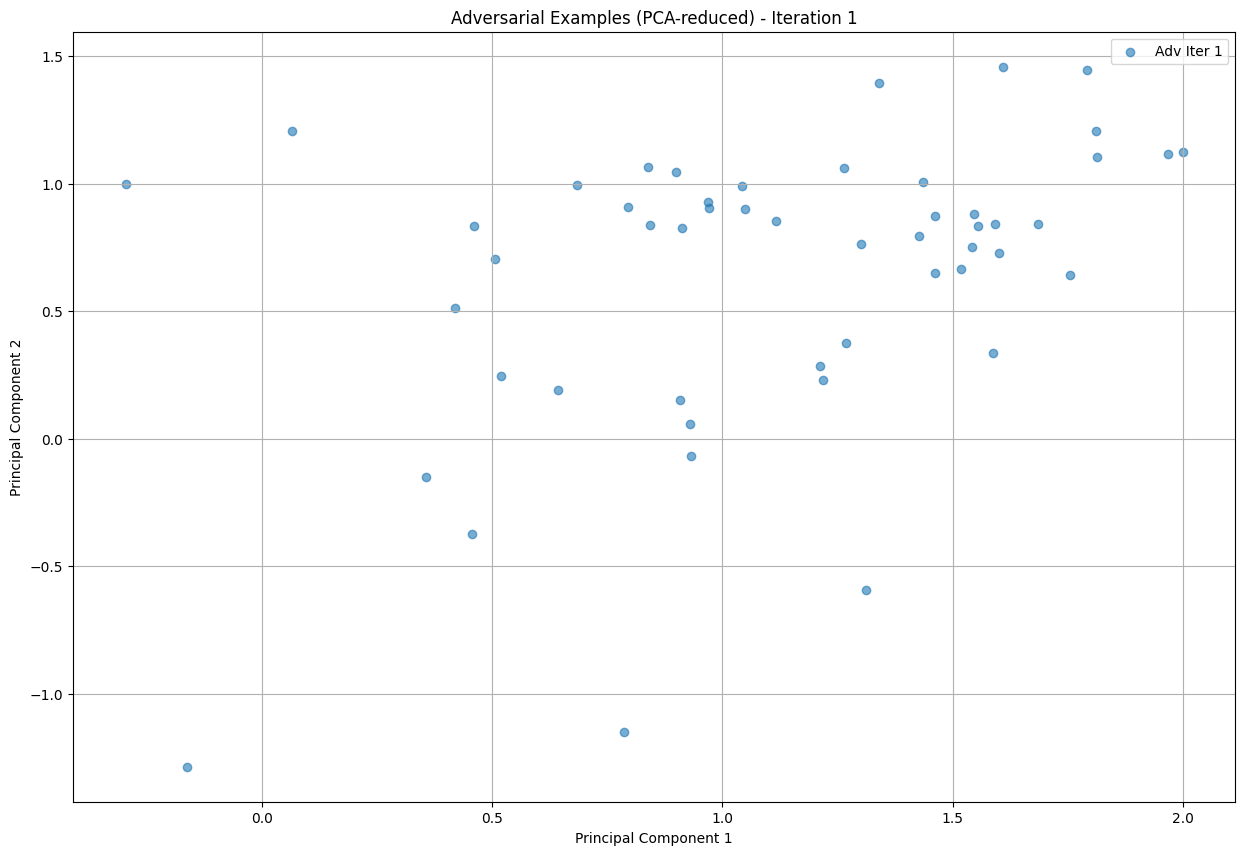

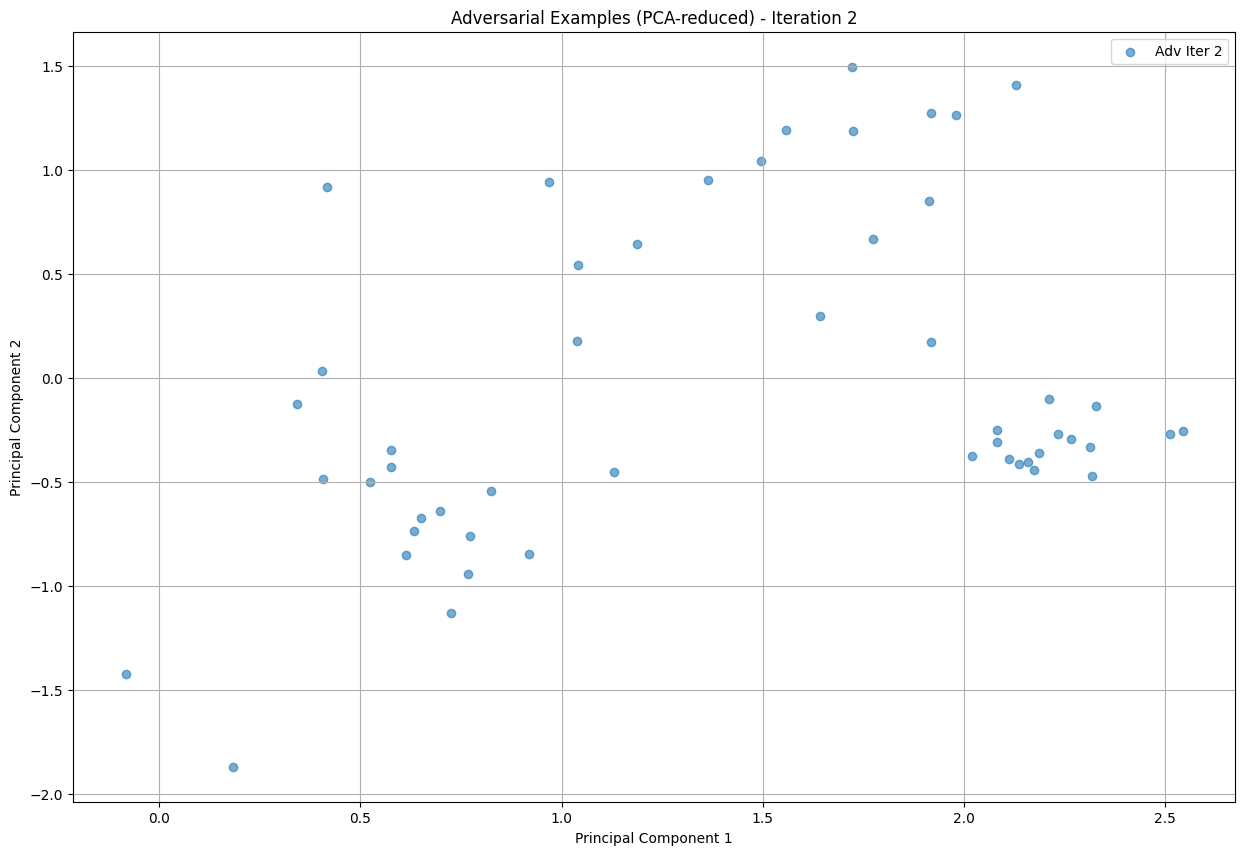

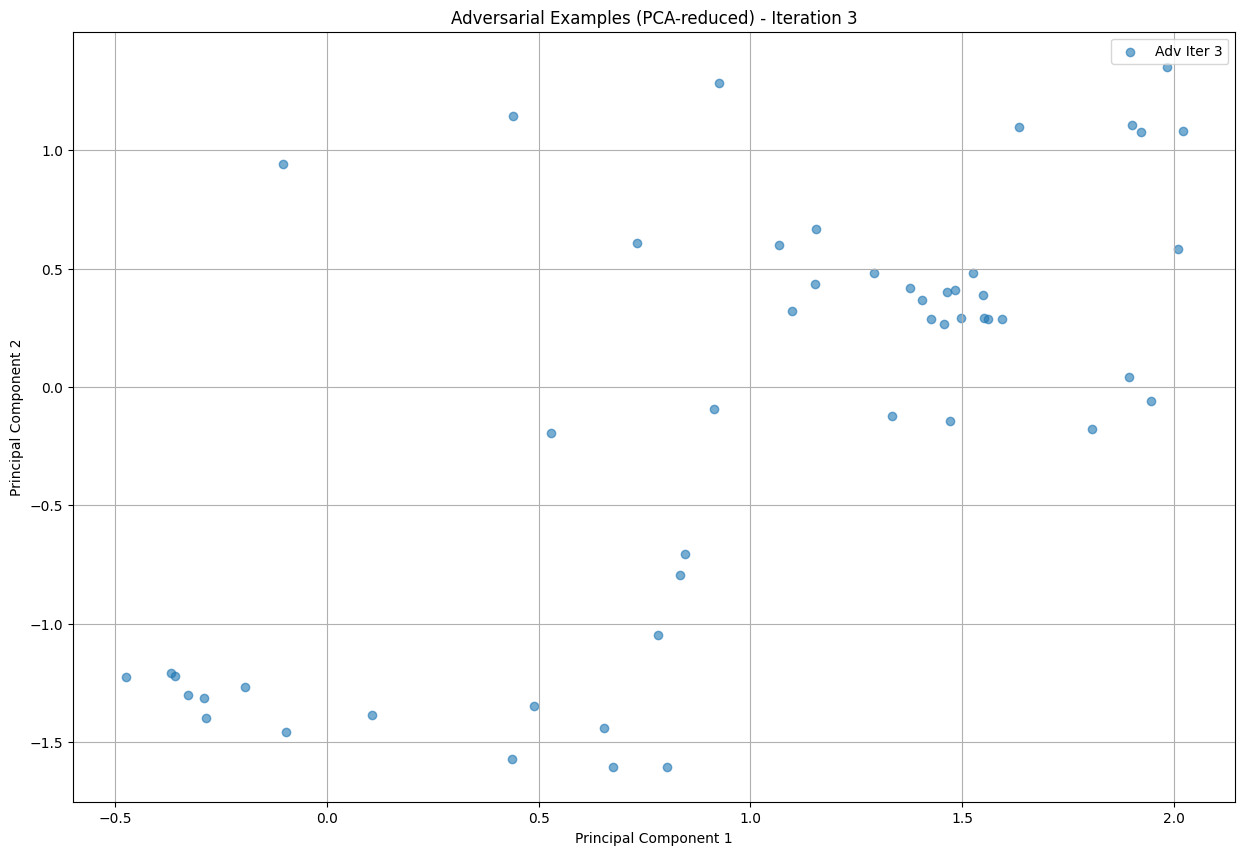

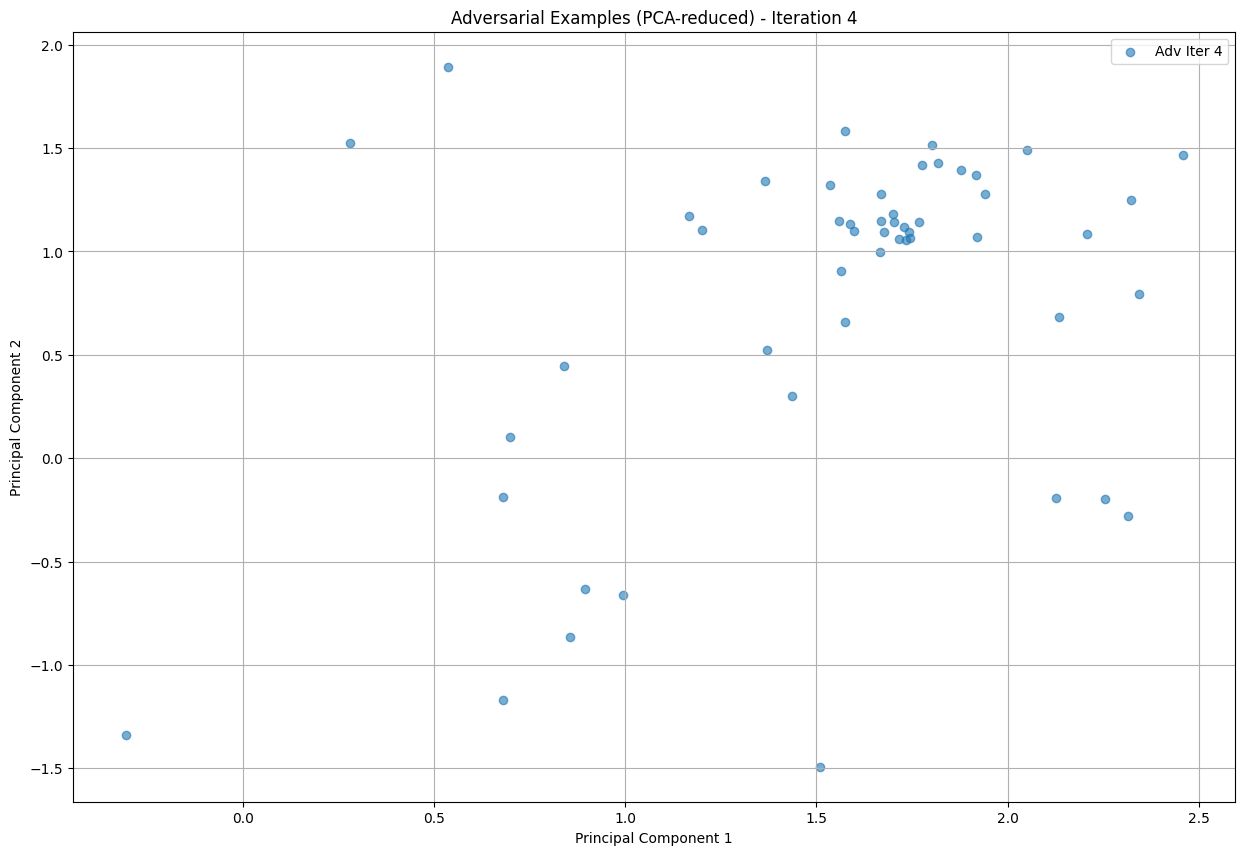

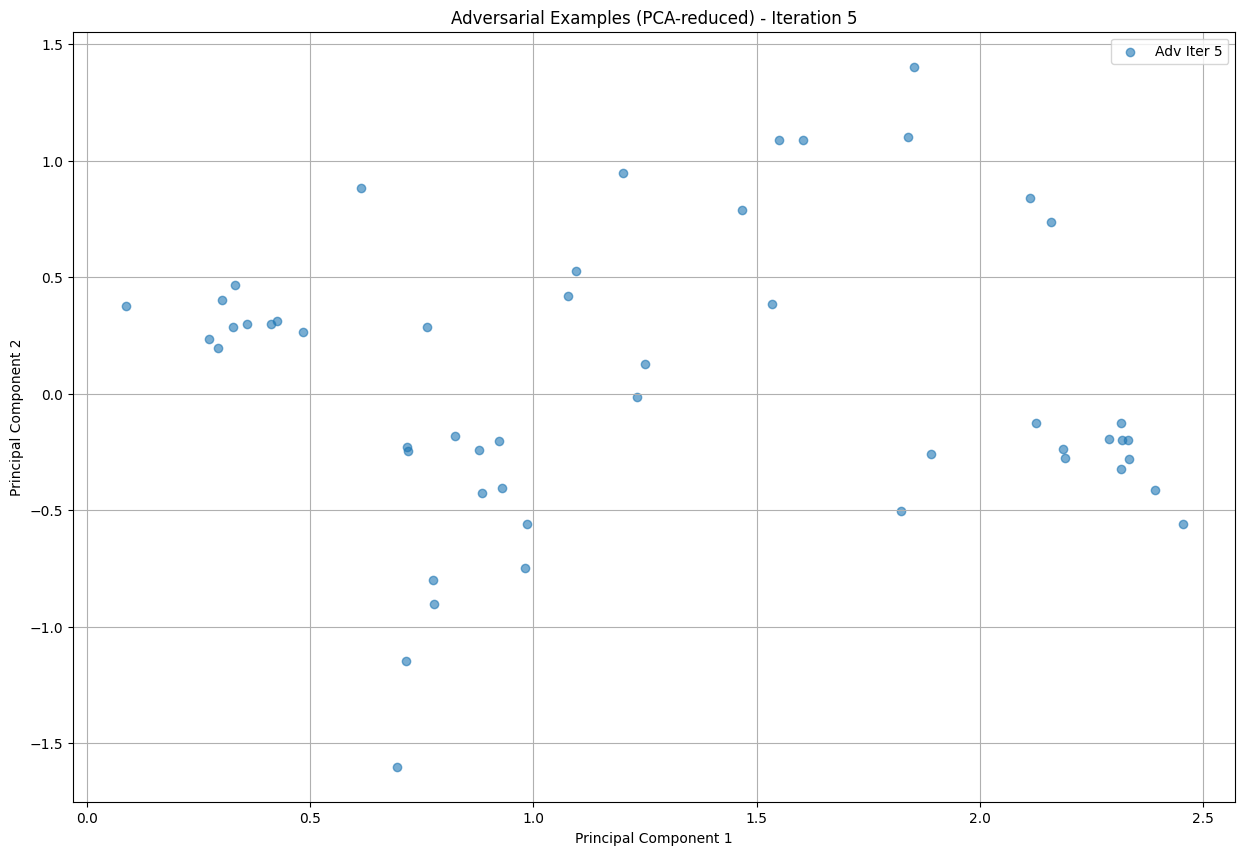

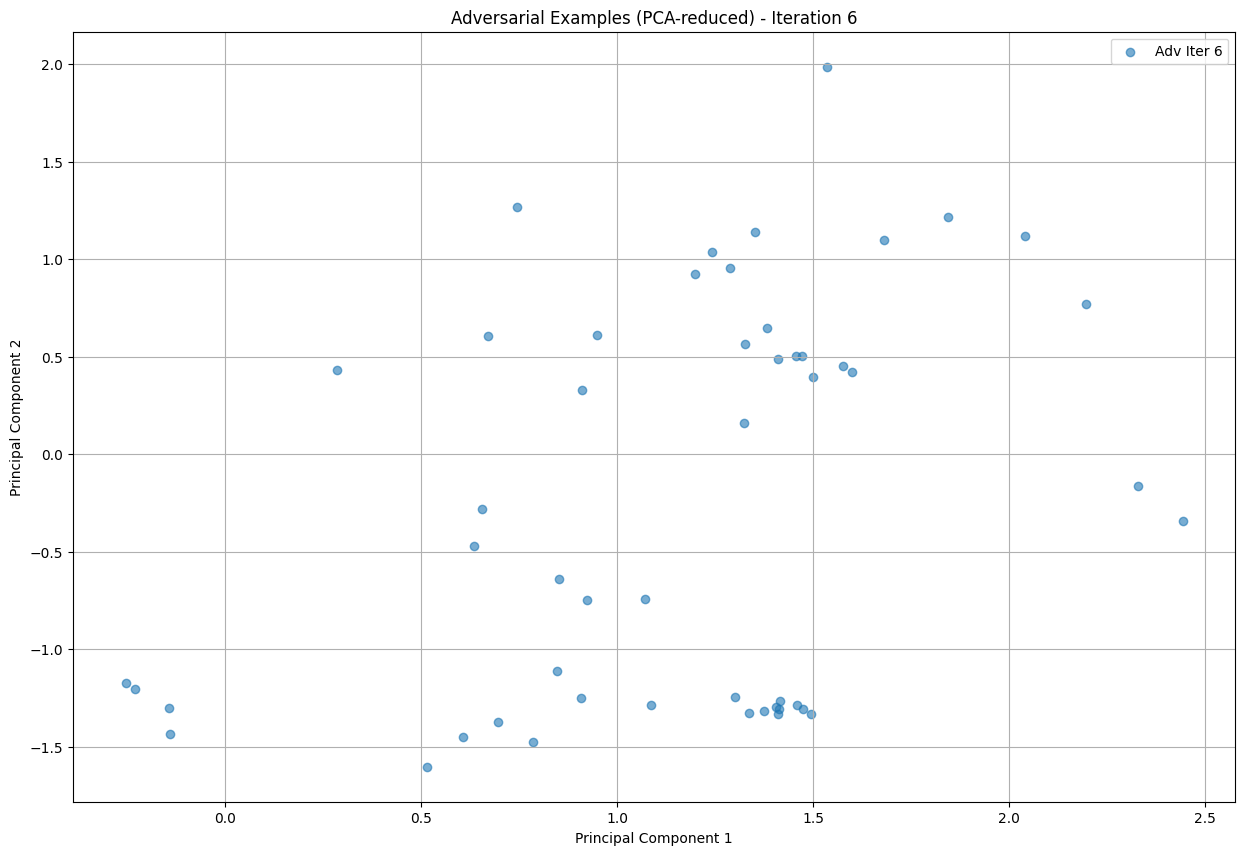

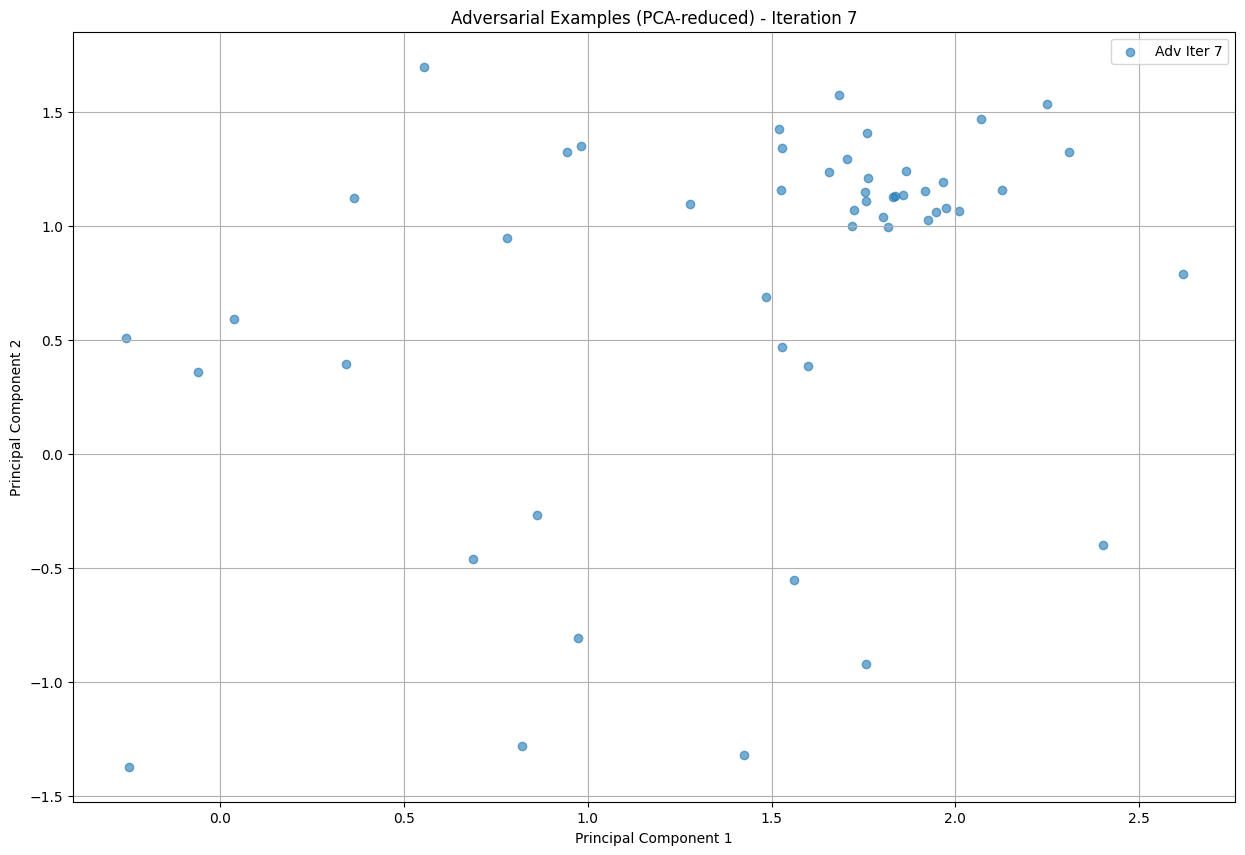

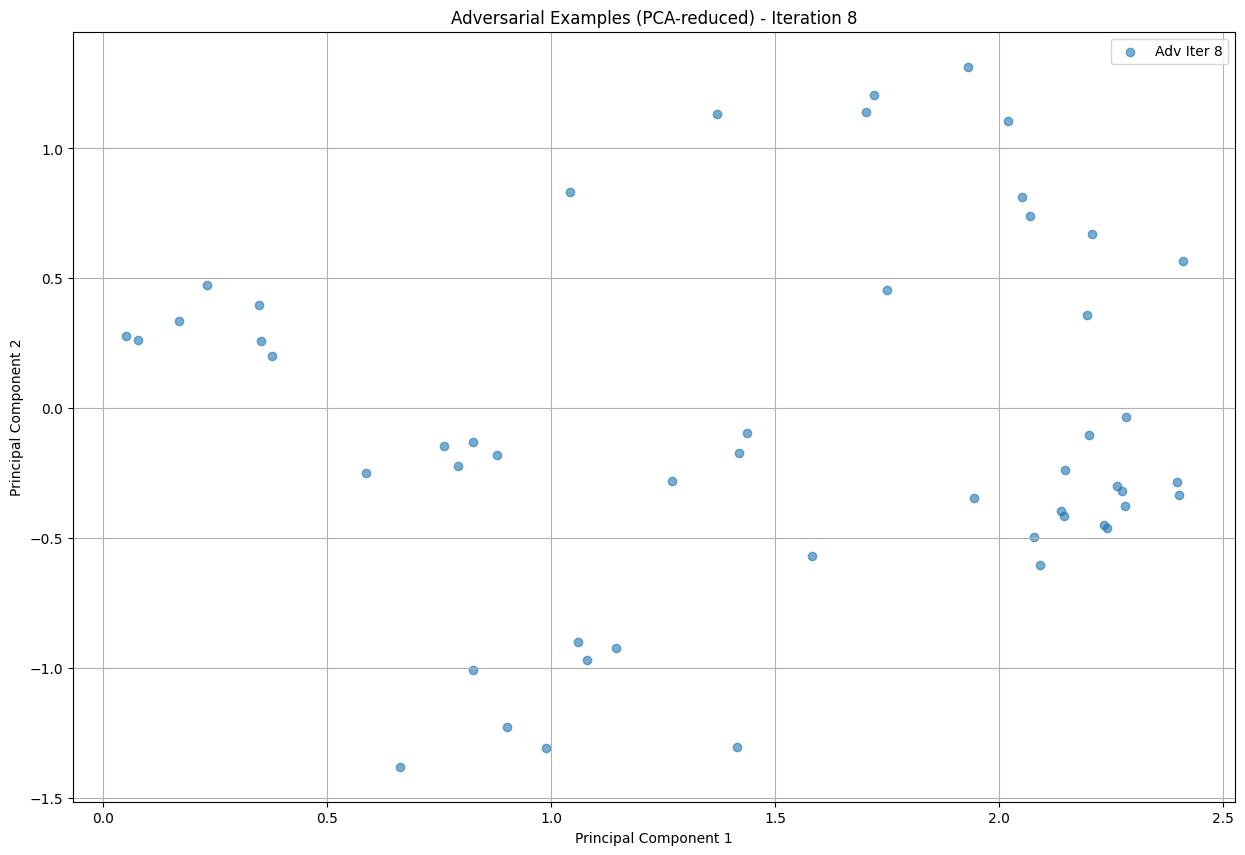

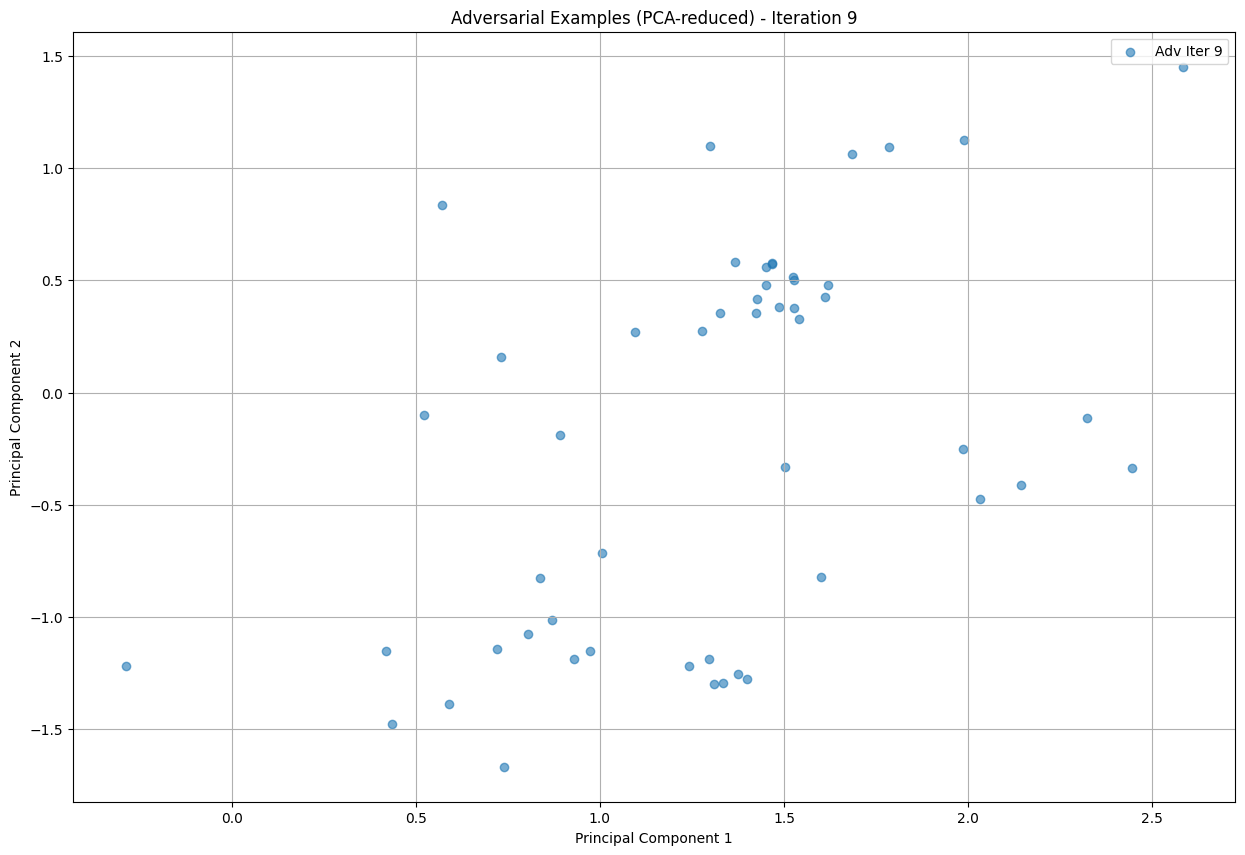

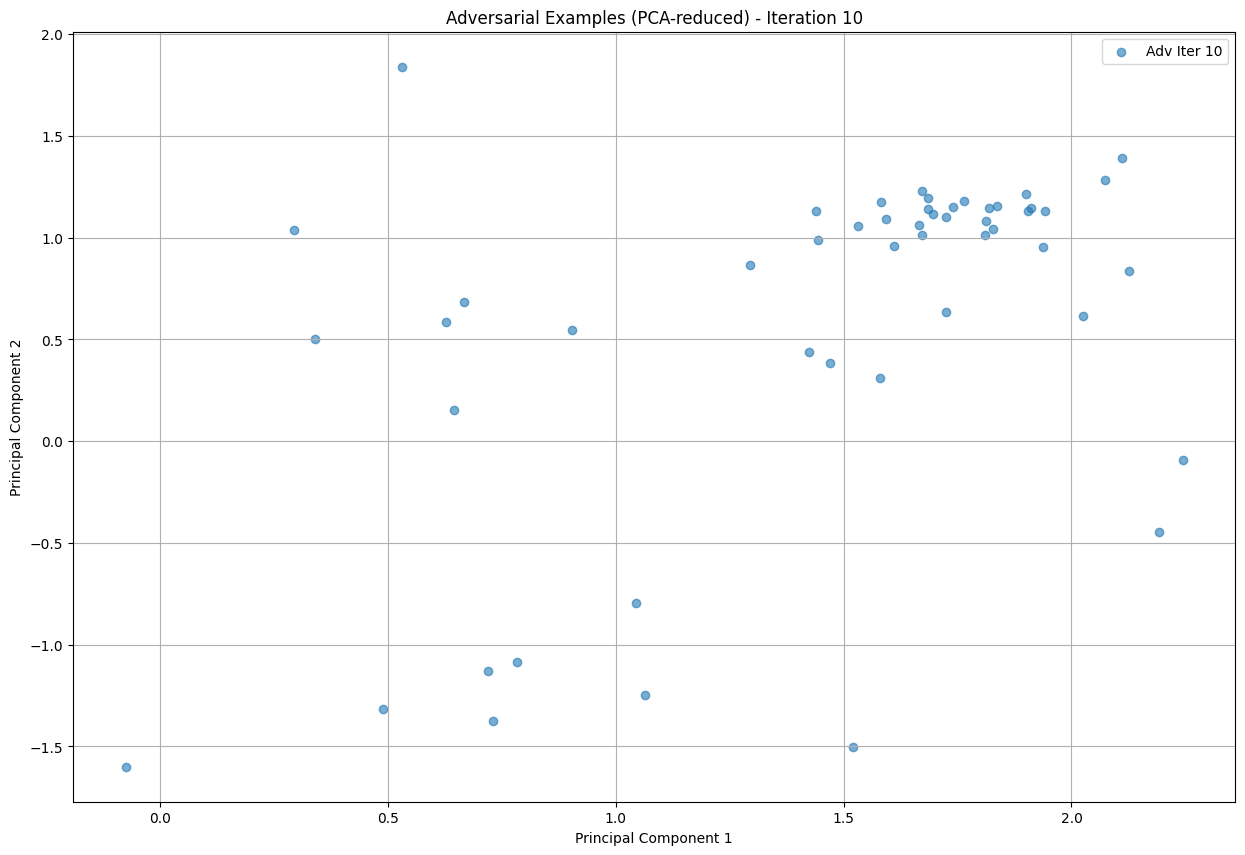

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize PGD attack
attack = ProjectedGradientDescent(estimator=classifier, eps=0.7, eps_step=0.1, max_iter=10)

# Perform PGD attack on the test set
X_test_adv = X_test.copy()

# Store the intermediate results
intermediate_results = []

for i in range(attack.max_iter):
    X_test_adv = attack.generate(X_test_adv)
    intermediate_results.append(pca.transform(X_test_adv).copy())  # Transform adversarial examples using PCA

# Plot the adversarial examples for each iteration
for iteration, X_adv_pca in enumerate(intermediate_results):
    plt.figure(figsize=(15, 10))
    plt.scatter(X_adv_pca[:, 0], X_adv_pca[:, 1], label=f'Adv Iter {iteration + 1}', alpha=0.6, cmap=plt.cm.Spectral)
    plt.title(f'Adversarial Examples (PCA-reduced) - Iteration {iteration + 1}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()


##  PGD Attack with XGBoost:

Accuracy before attack: 88.24%
Iteration 1: Accuracy = 43.14%
Iteration 2: Accuracy = 50.98%
Iteration 3: Accuracy = 35.29%
Iteration 4: Accuracy = 37.25%
Iteration 5: Accuracy = 31.37%
Iteration 6: Accuracy = 27.45%
Iteration 7: Accuracy = 31.37%
Iteration 8: Accuracy = 29.41%
Iteration 9: Accuracy = 29.41%
Iteration 10: Accuracy = 21.57%


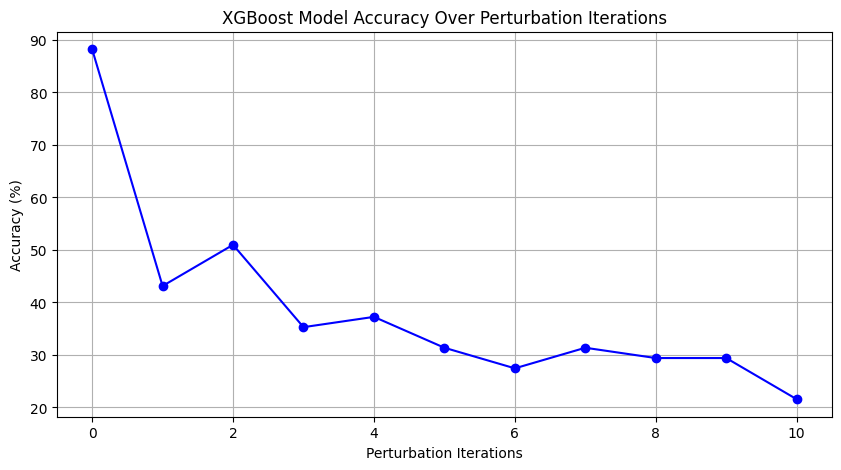

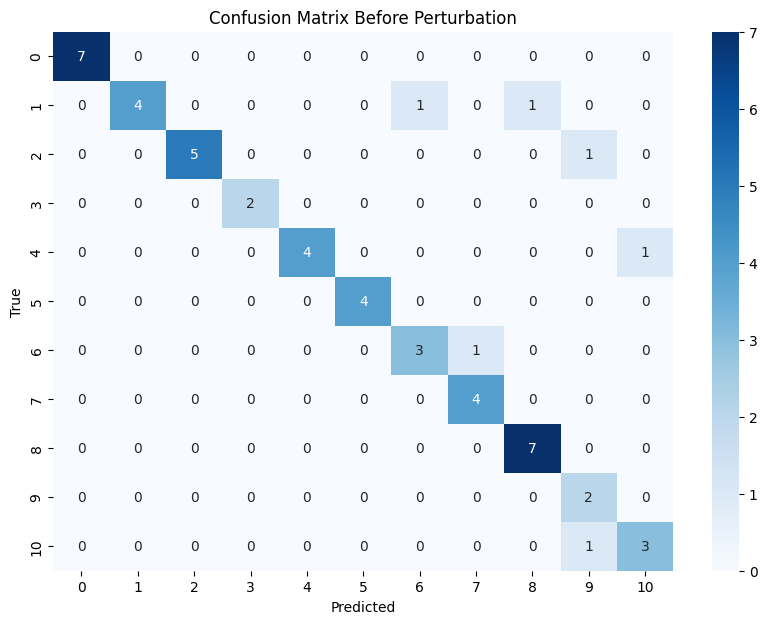

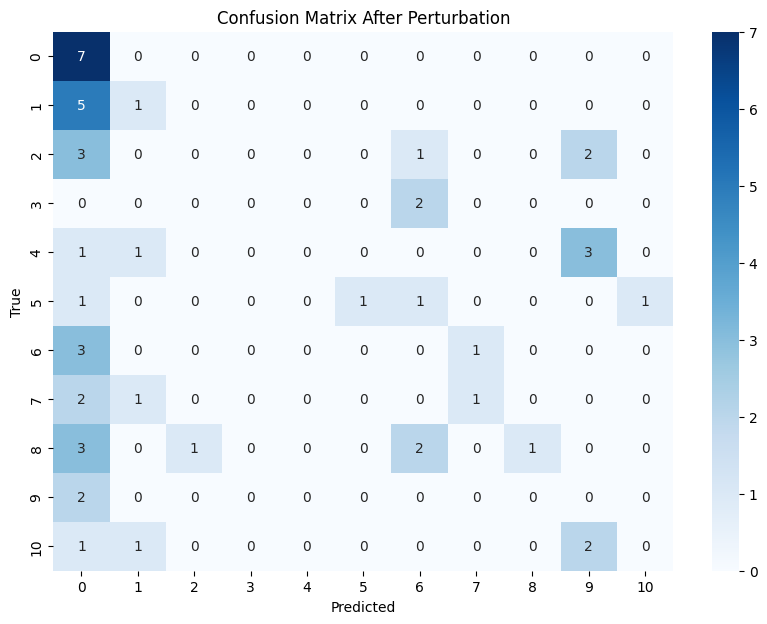

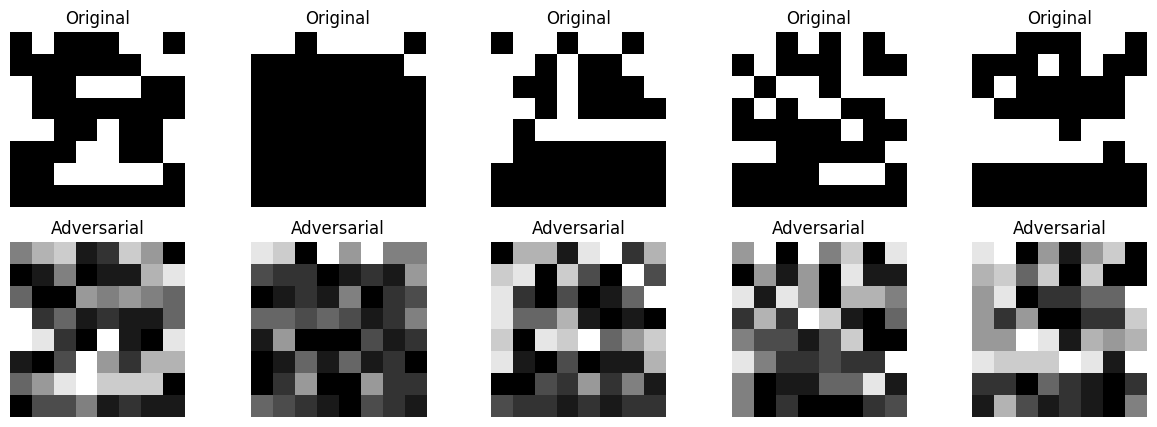

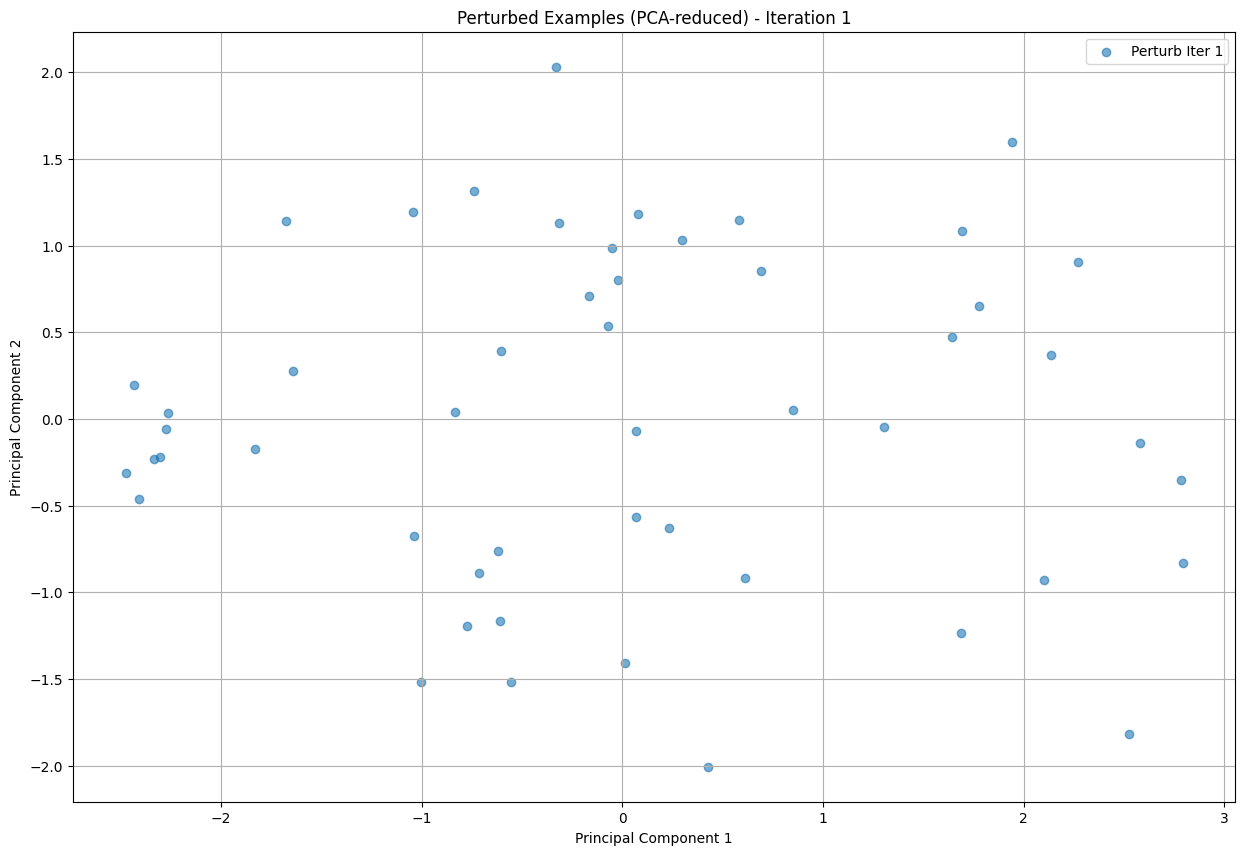

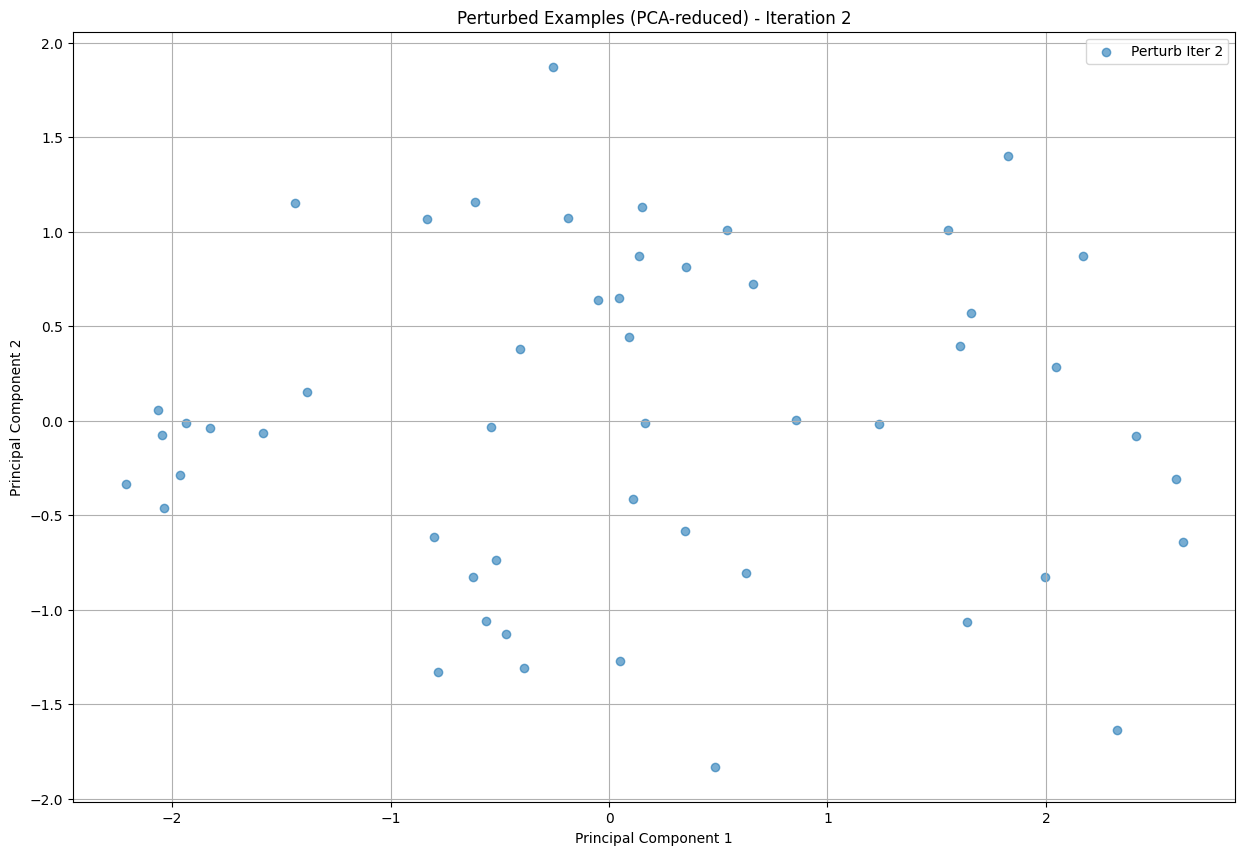

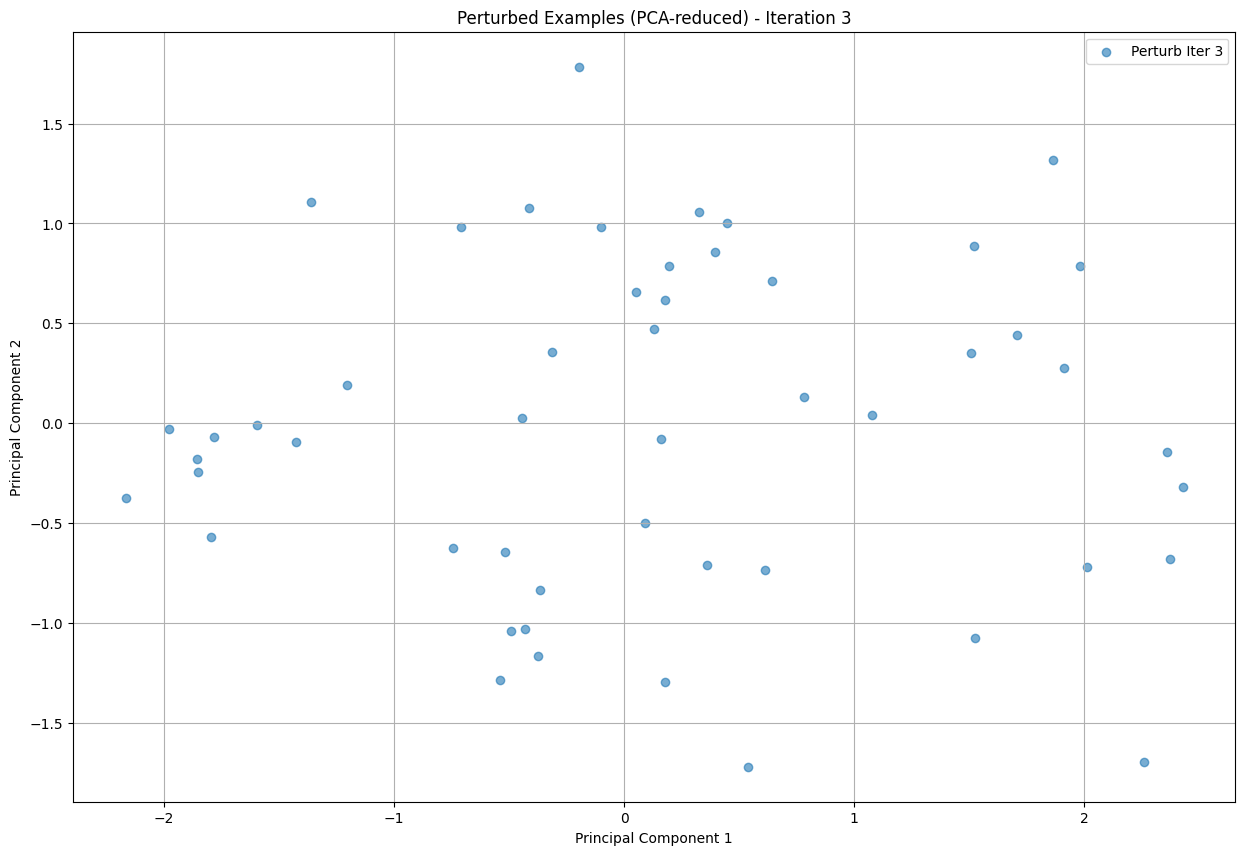

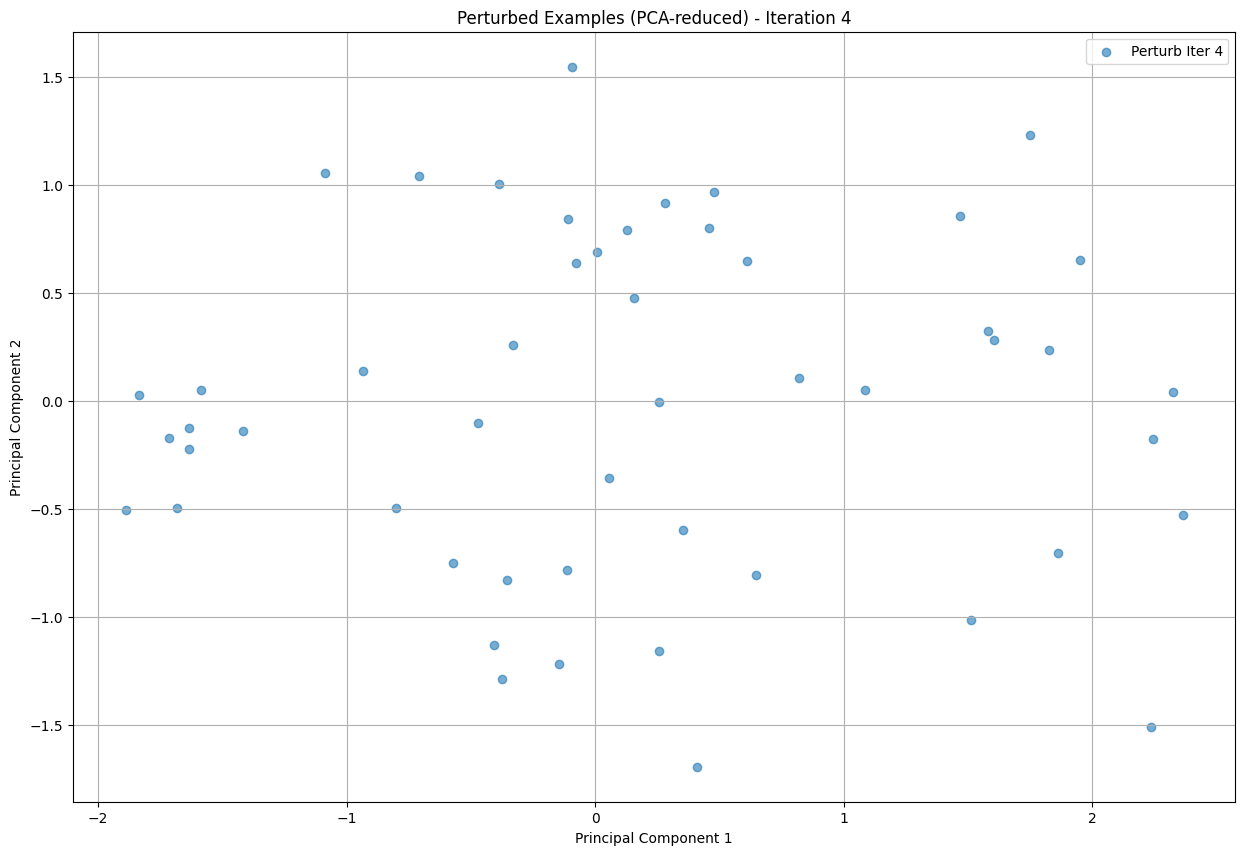

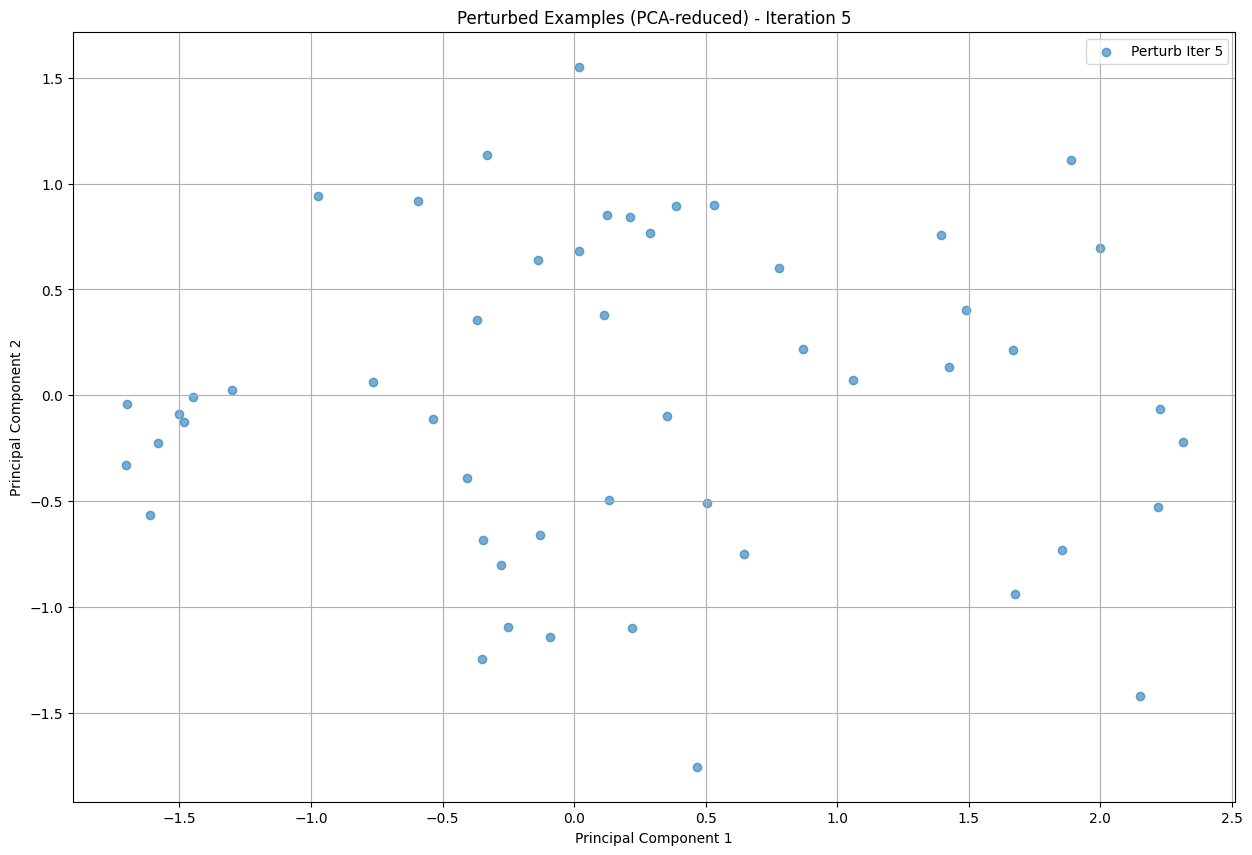

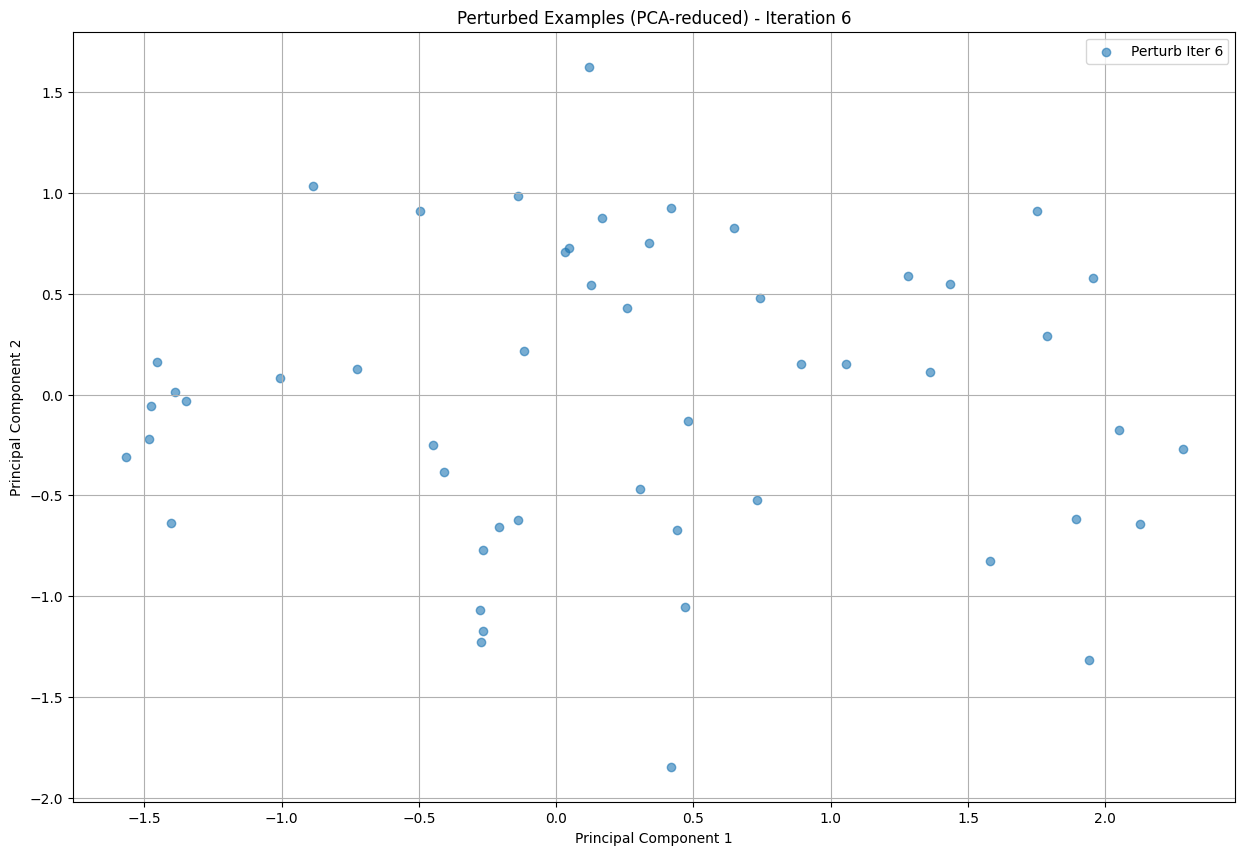

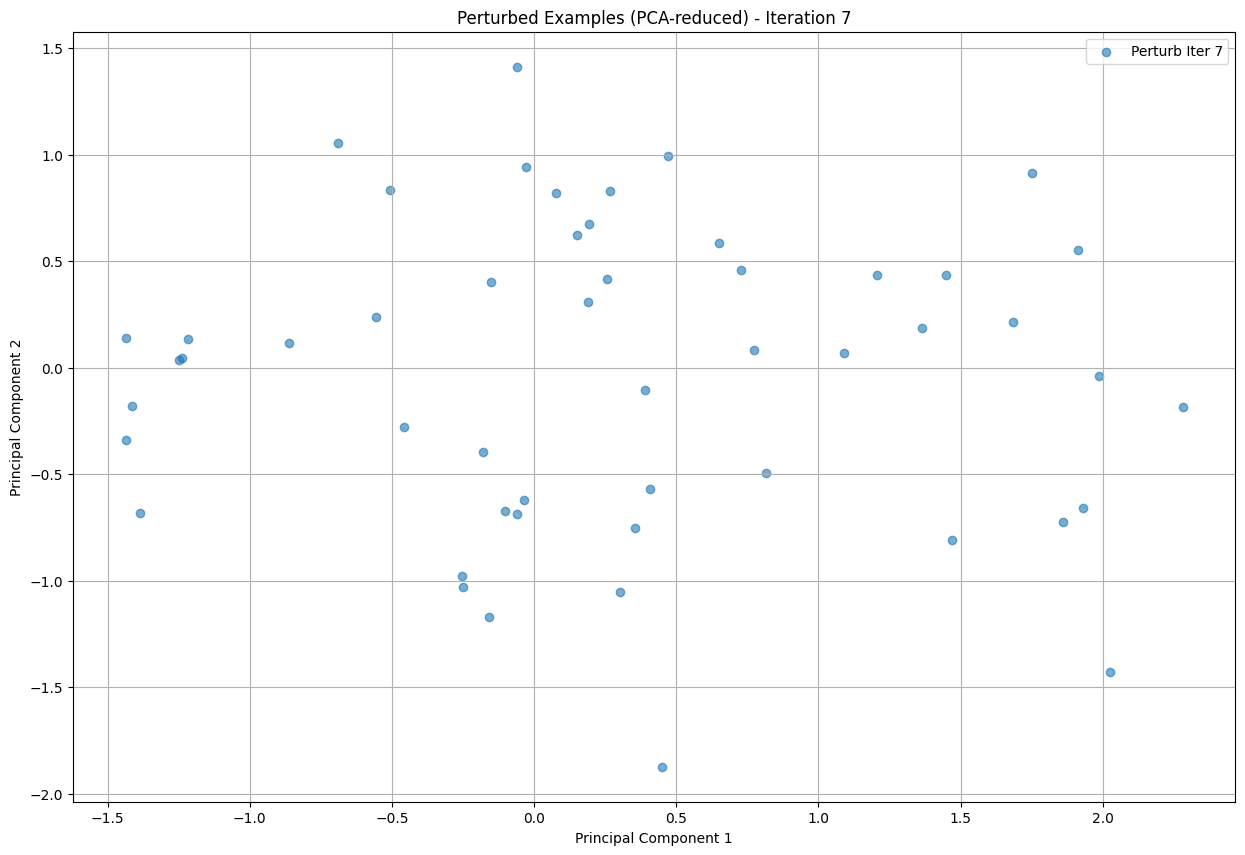

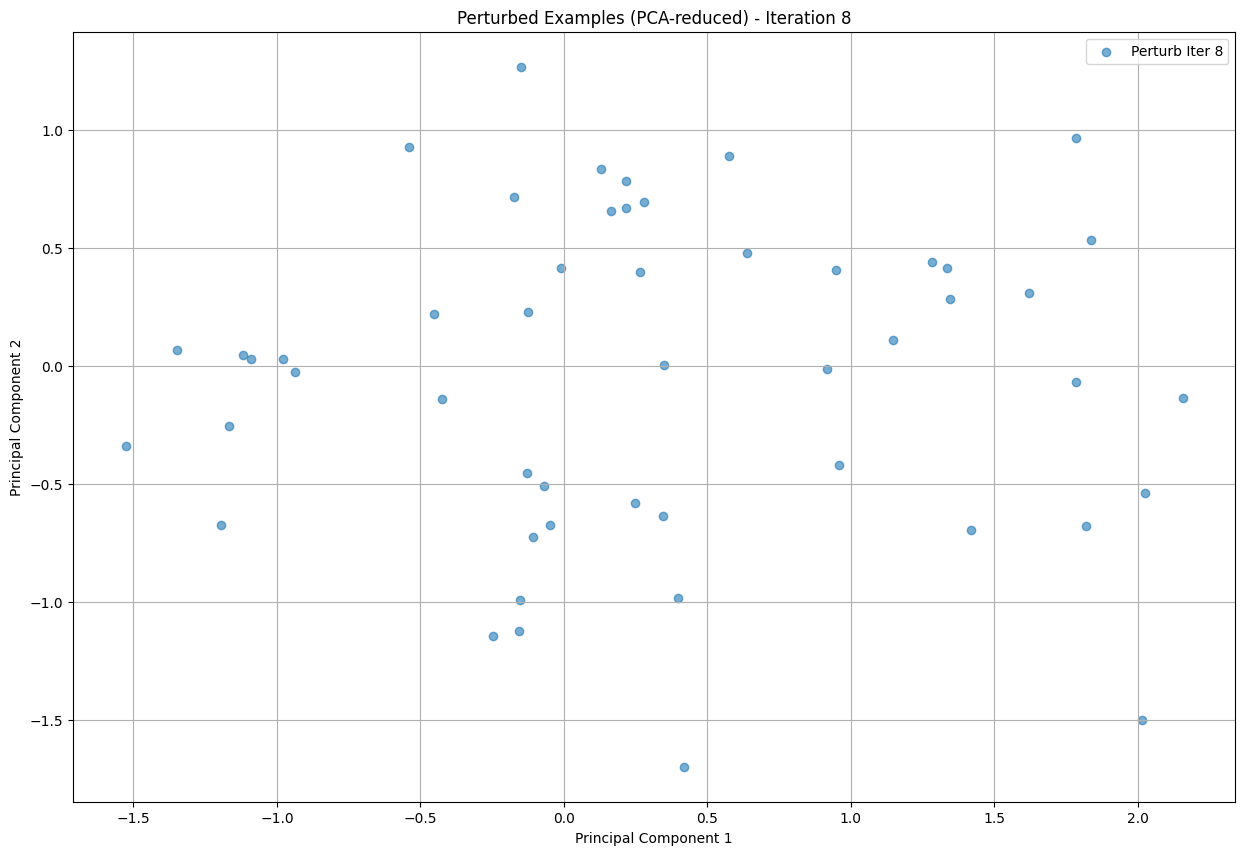

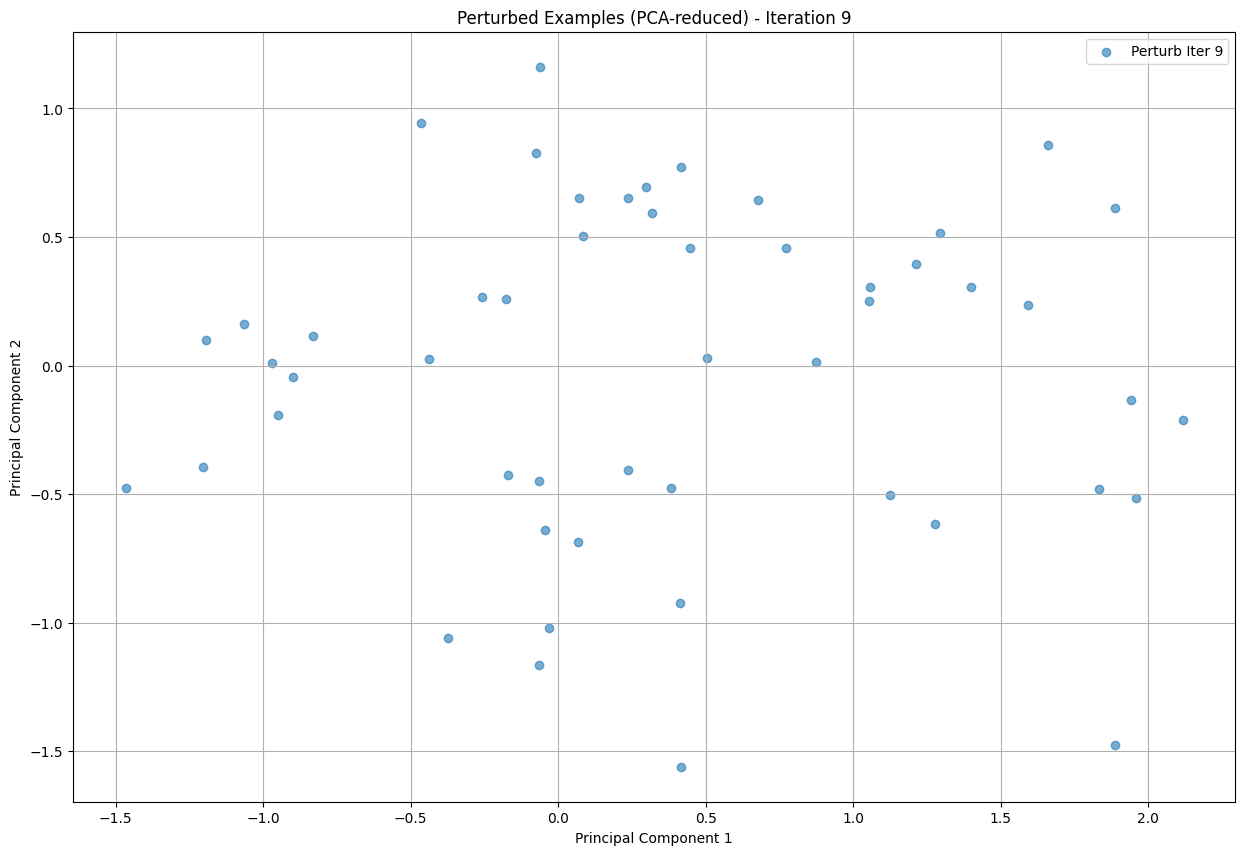

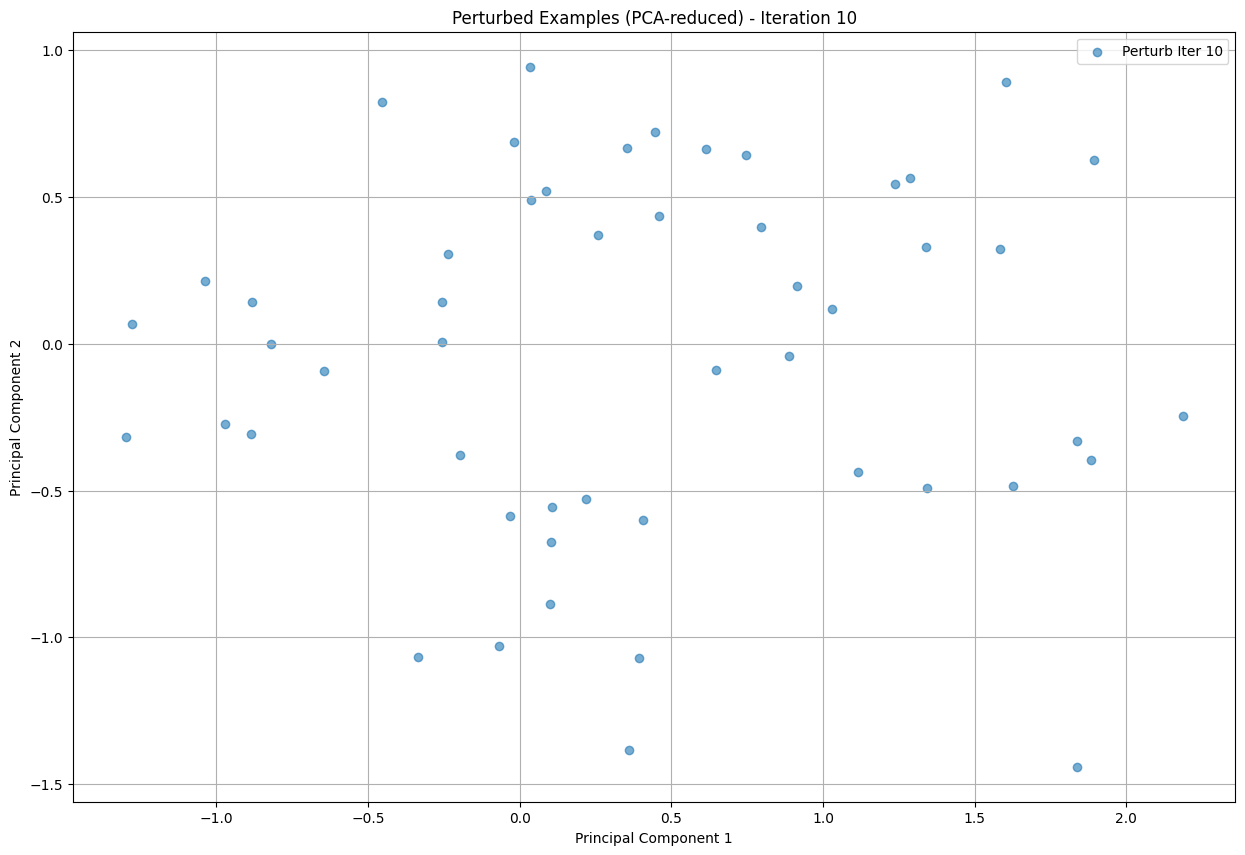

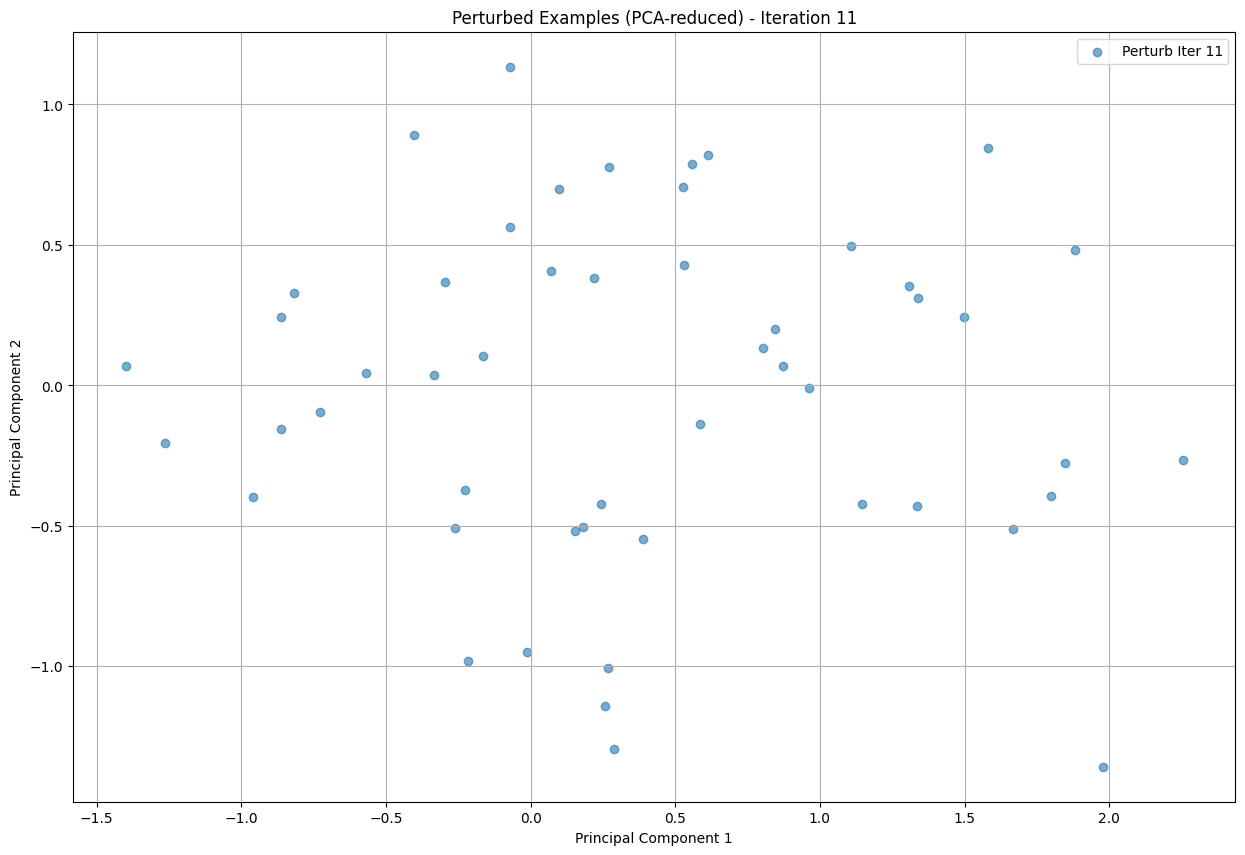

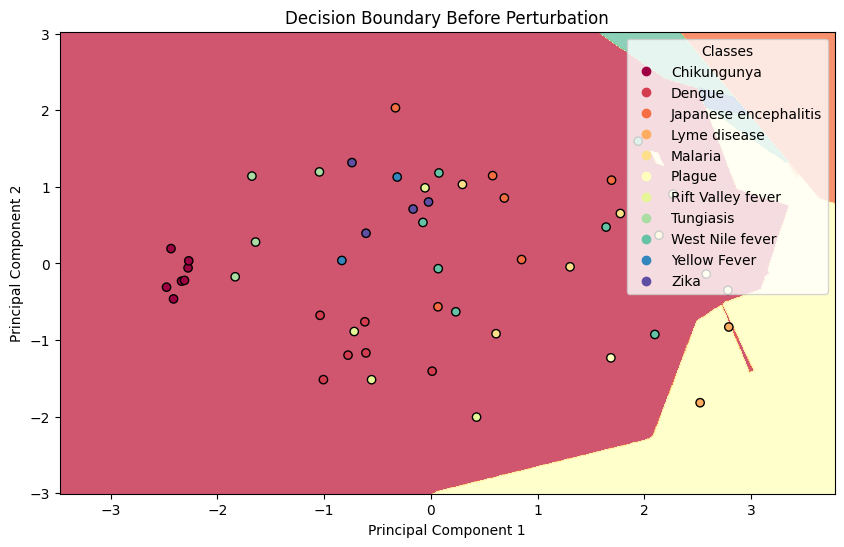

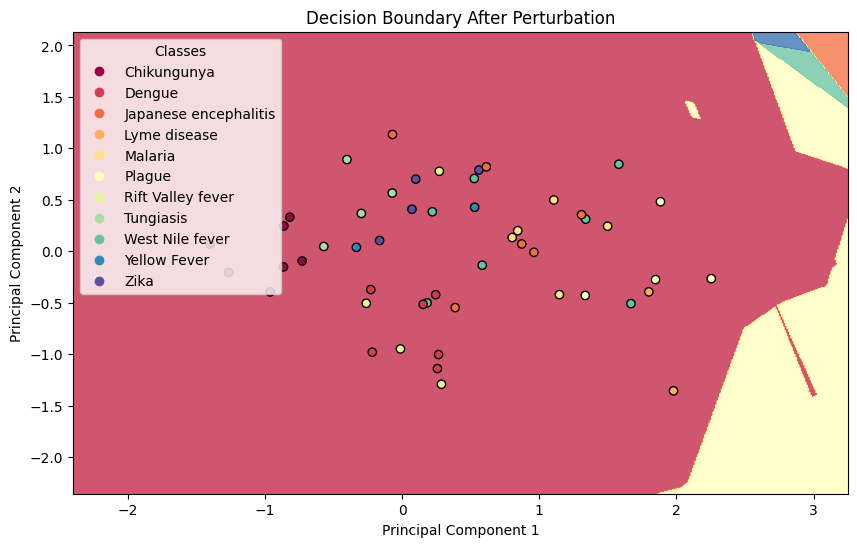

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values


# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Initial predictions and accuracy
y_pred = xgb_model.predict(X_test)
accuracy_before_attack = accuracy_score(y_test, y_pred)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Initialize perturbations
eps = 0.1  # Perturbation magnitude
max_iter = 10  # Number of iterations

# Store the intermediate results
intermediate_results = []
accuracies = [accuracy_before_attack * 100]

# Perform manual perturbations on the test set
X_test_adv = X_test.copy()
intermediate_results.append(X_test.copy())

for i in range(max_iter):
    perturbation = eps * np.sign(np.random.randn(*X_test.shape))
    X_test_adv = np.clip(X_test_adv + perturbation, 0, 1)  # Ensure values are within valid range
    y_pred_adv = xgb_model.predict(X_test_adv)
    accuracy = accuracy_score(y_test, y_pred_adv)
    accuracies.append(accuracy * 100)
    intermediate_results.append(X_test_adv.copy())
    print(f"Iteration {i + 1}: Accuracy = {accuracy * 100:.2f}%")

# Plot model accuracy over perturbation iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Perturbation Iterations')
plt.ylabel('Accuracy (%)')
plt.title('XGBoost Model Accuracy Over Perturbation Iterations')
plt.grid(True)
plt.show()

# Confusion matrix before attack
cm_before = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before Perturbation')
plt.show()

# Confusion matrix after attack
cm_after = confusion_matrix(y_test, y_pred_adv)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After Perturbation')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)
intermediate_results_pca = [pca.transform(X_adv) for X_adv in intermediate_results]

# Plot the adversarial examples for each iteration
for iteration, X_adv_pca in enumerate(intermediate_results_pca):
    plt.figure(figsize=(15, 10))
    plt.scatter(X_adv_pca[:, 0], X_adv_pca[:, 1], label=f'Perturb Iter {iteration + 1}', alpha=0.6, cmap=plt.cm.Spectral)
    plt.title(f'Perturbed Examples (PCA-reduced) - Iteration {iteration + 1}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot decision boundaries before and after attack
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
     # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, xgb_model, 'Decision Boundary Before Perturbation')
plot_decision_boundary(intermediate_results_pca[-1], y_test, xgb_model, 'Decision Boundary After Perturbation')


## PGD Attack with ANN:

Epoch 1/10
21/21 [==============================] - 0s 1ms/step - loss: 2.3128 - accuracy: 0.1940
Epoch 2/10
21/21 [==============================] - 0s 3ms/step - loss: 1.9712 - accuracy: 0.5025
Epoch 3/10
21/21 [==============================] - 0s 4ms/step - loss: 1.5668 - accuracy: 0.7214
Epoch 4/10
21/21 [==============================] - 0s 1ms/step - loss: 1.1240 - accuracy: 0.8756
Epoch 5/10
21/21 [==============================] - 0s 4ms/step - loss: 0.7653 - accuracy: 0.9055
Epoch 6/10
21/21 [==============================] - 0s 1ms/step - loss: 0.5214 - accuracy: 0.9751
Epoch 7/10
21/21 [==============================] - 0s 1ms/step - loss: 0.3435 - accuracy: 0.9801
Epoch 8/10
21/21 [==============================] - 0s 4ms/step - loss: 0.2619 - accuracy: 0.9851
Epoch 9/10
21/21 [==============================] - 0s 2ms/step - loss: 0.1808 - accuracy: 0.9900
Epoch 10/10
21/21 [==============================] - 0s 4ms/step - loss: 0.1418 - accuracy: 0.9950
Accuracy before att

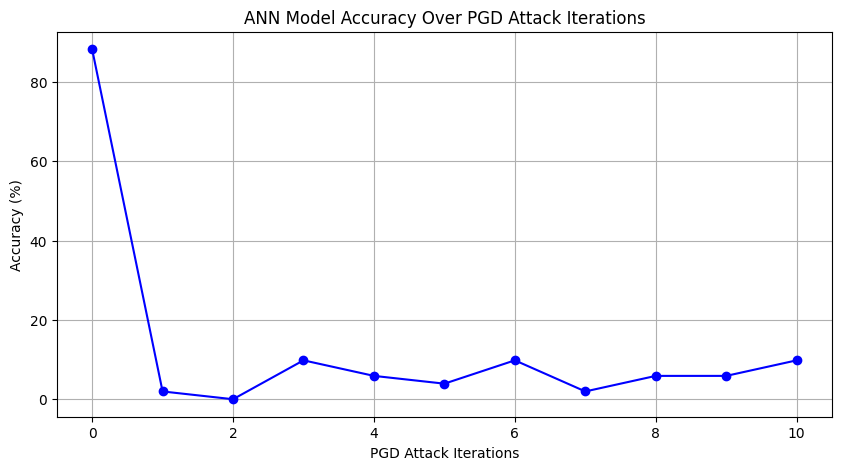

2/2 [==============================] - 0s 3ms/step


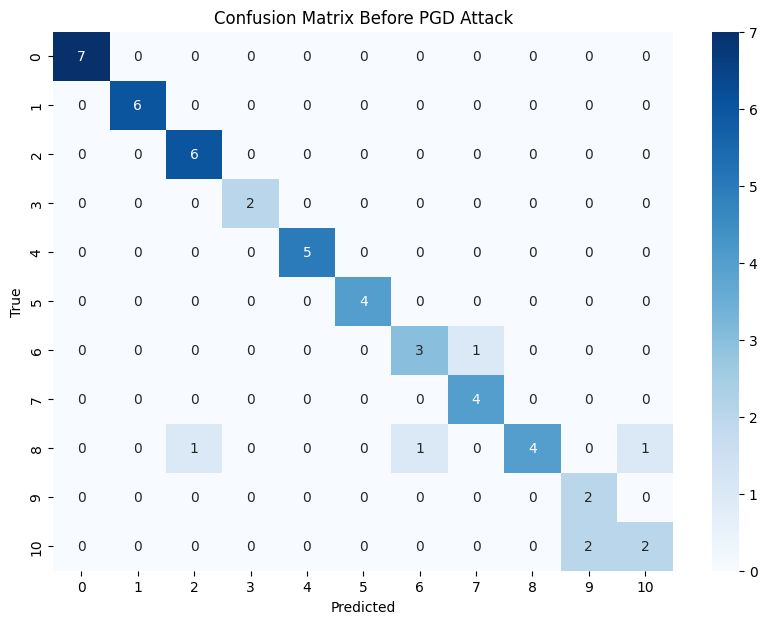

2/2 [==============================] - 0s 3ms/step


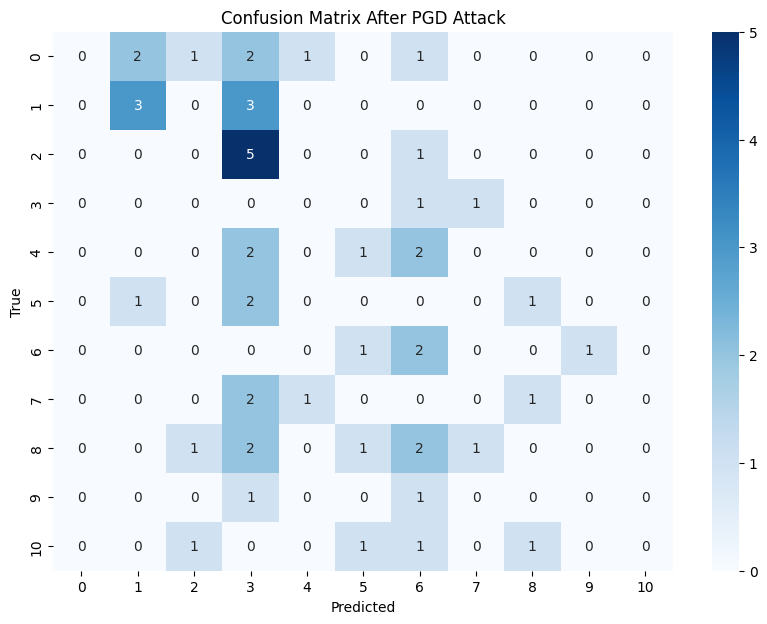

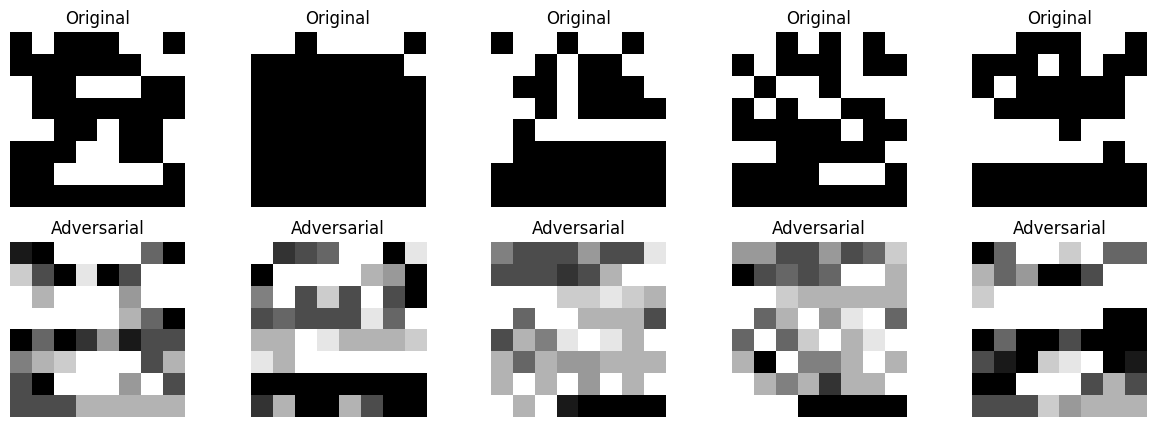

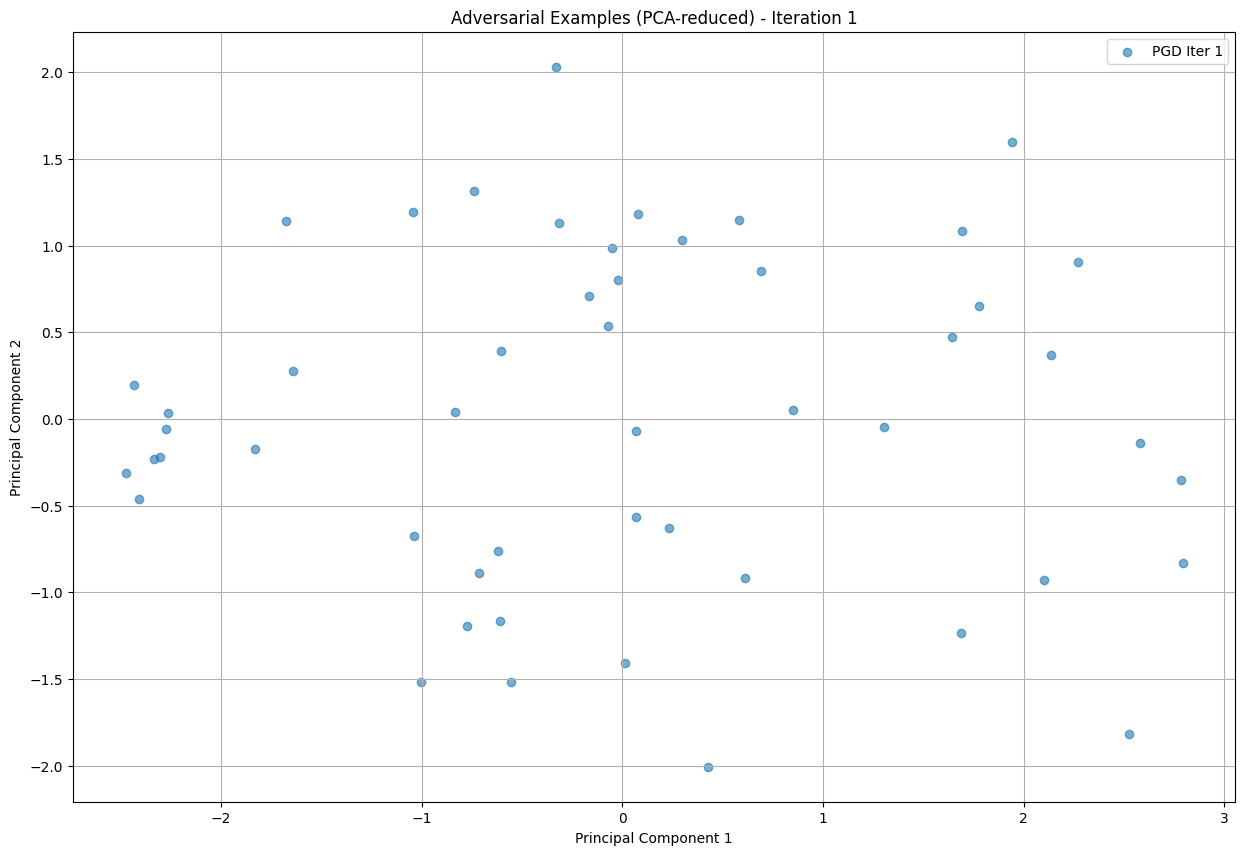

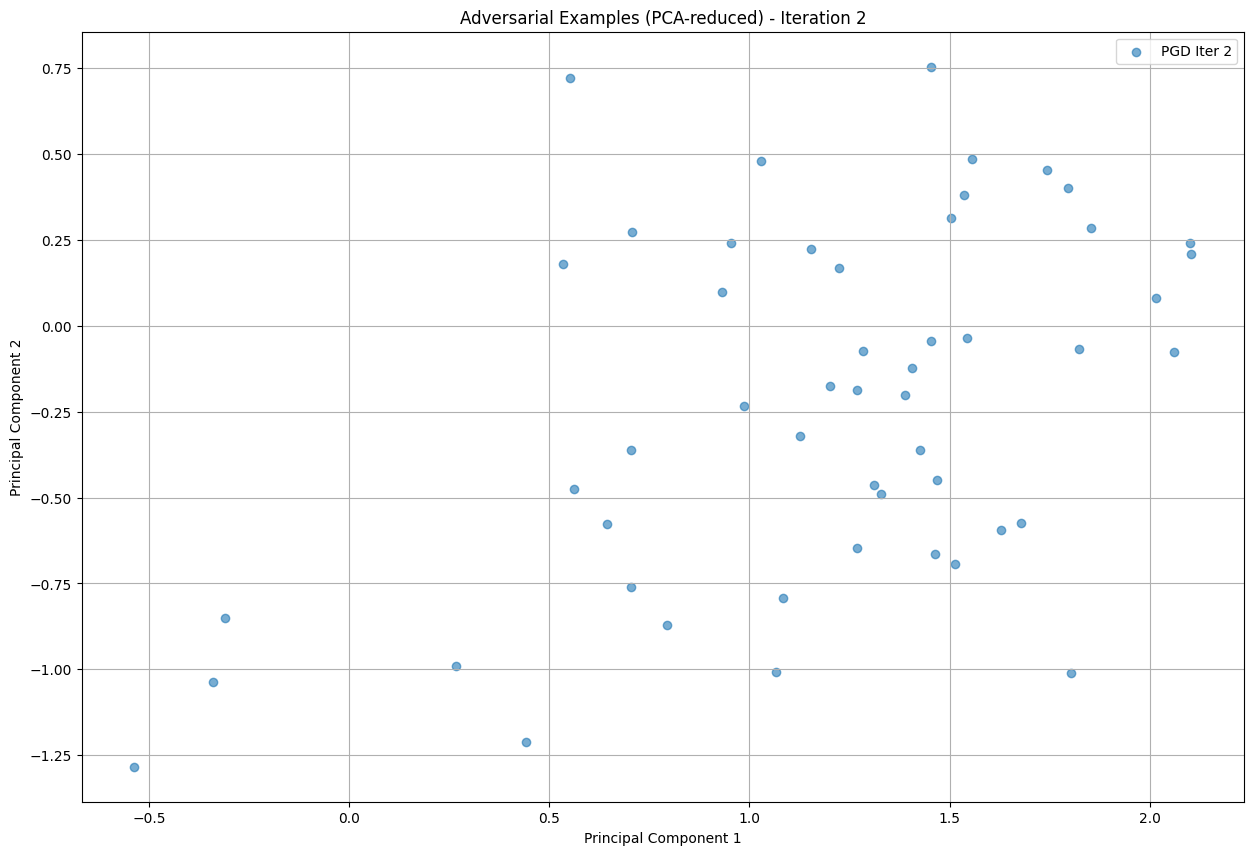

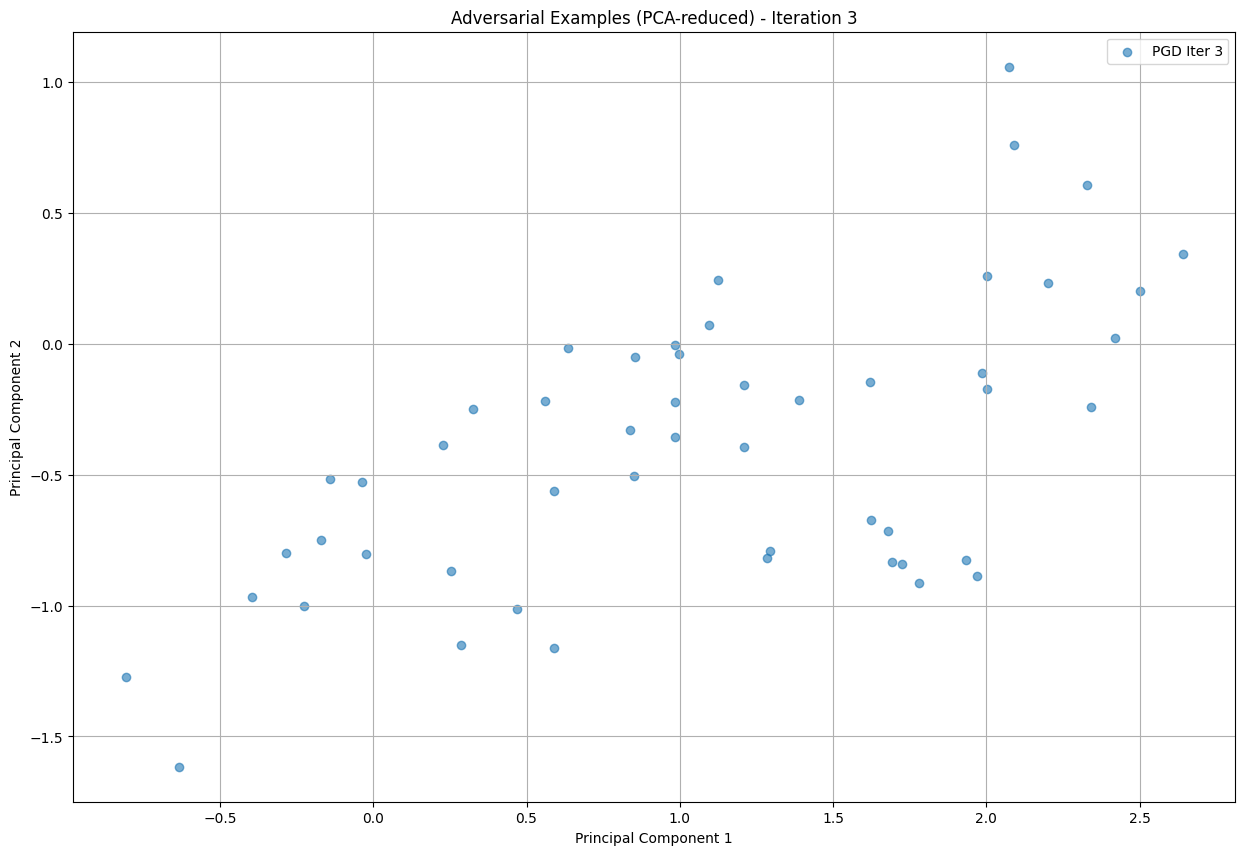

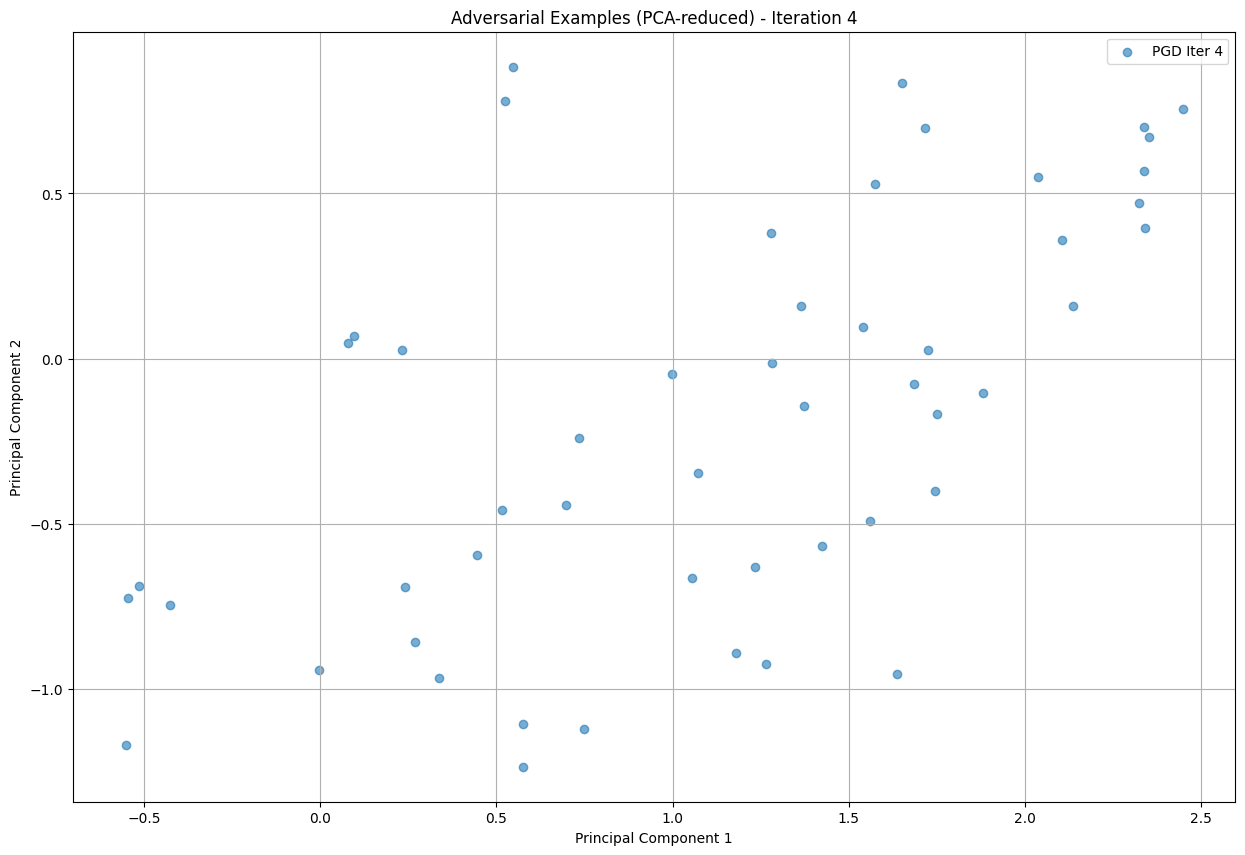

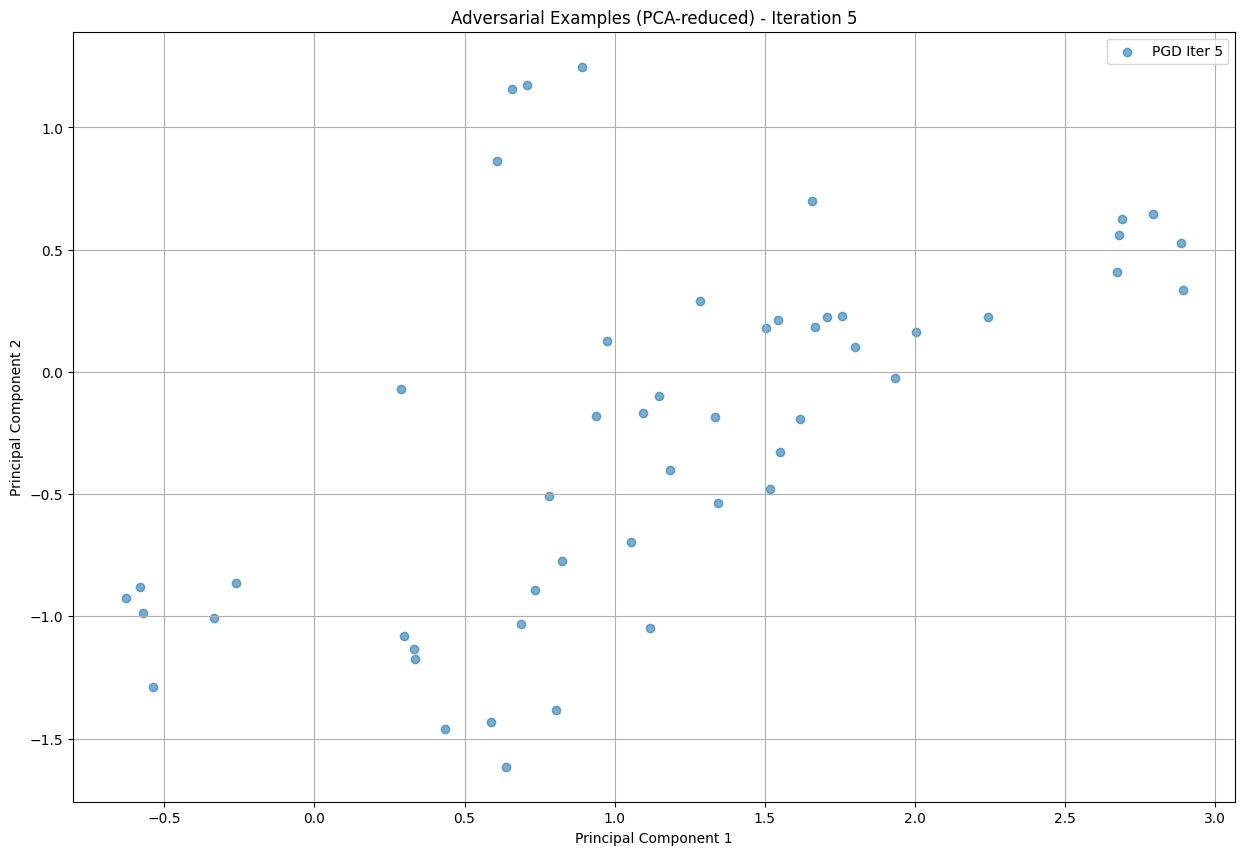

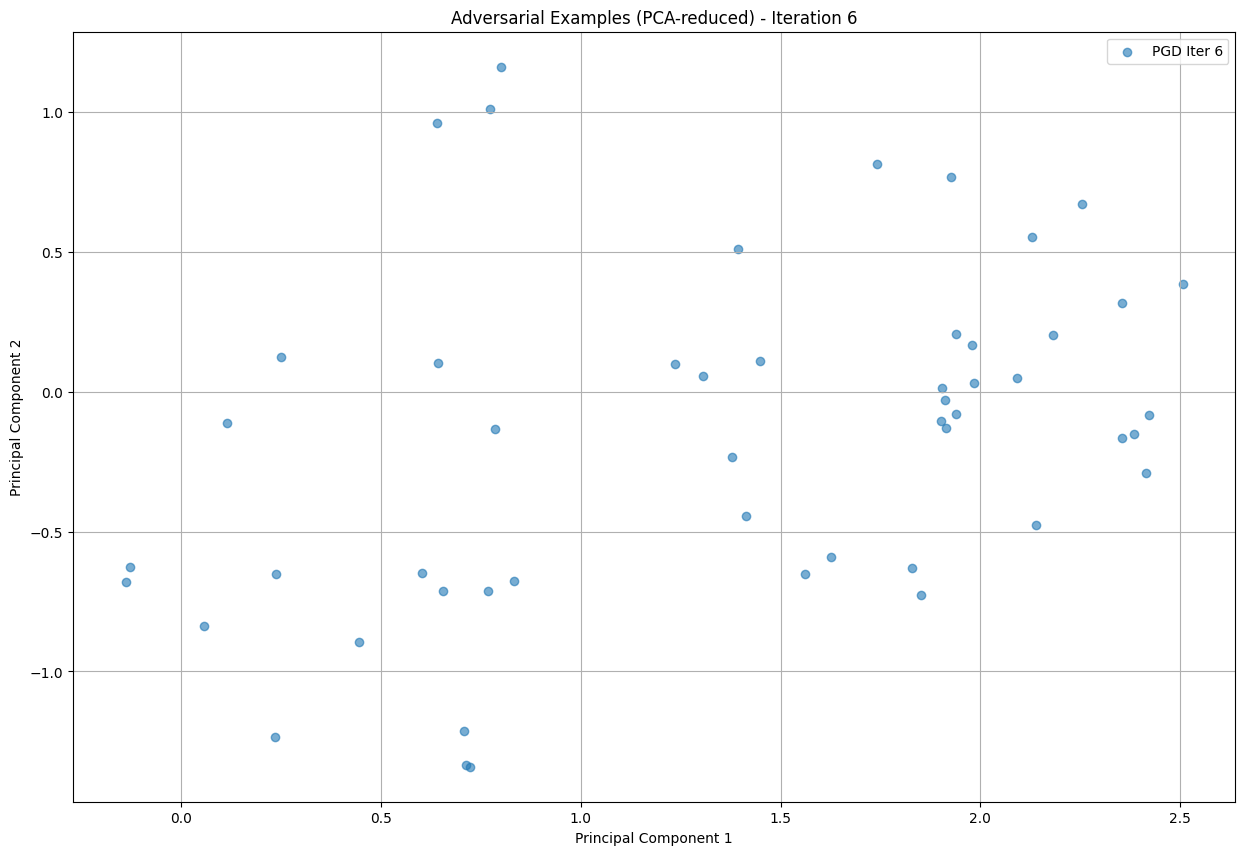

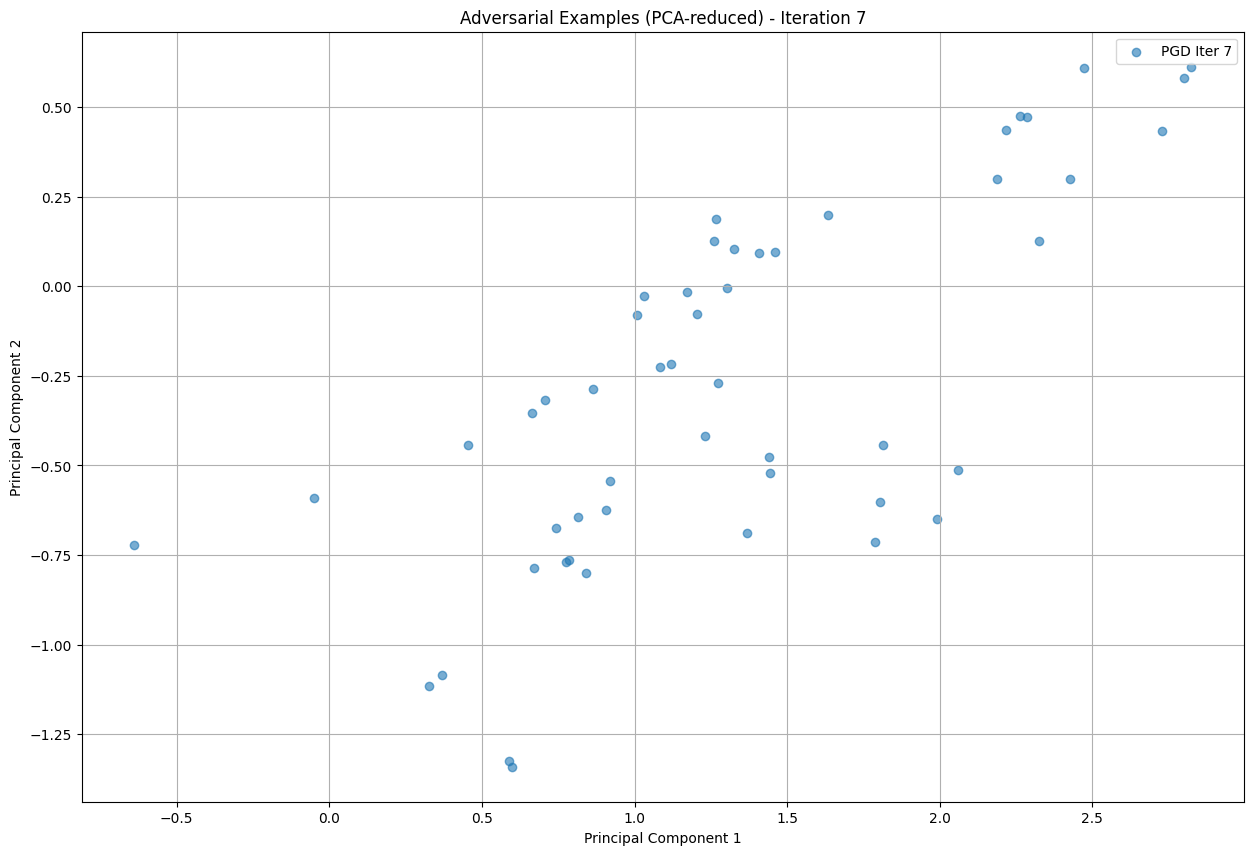

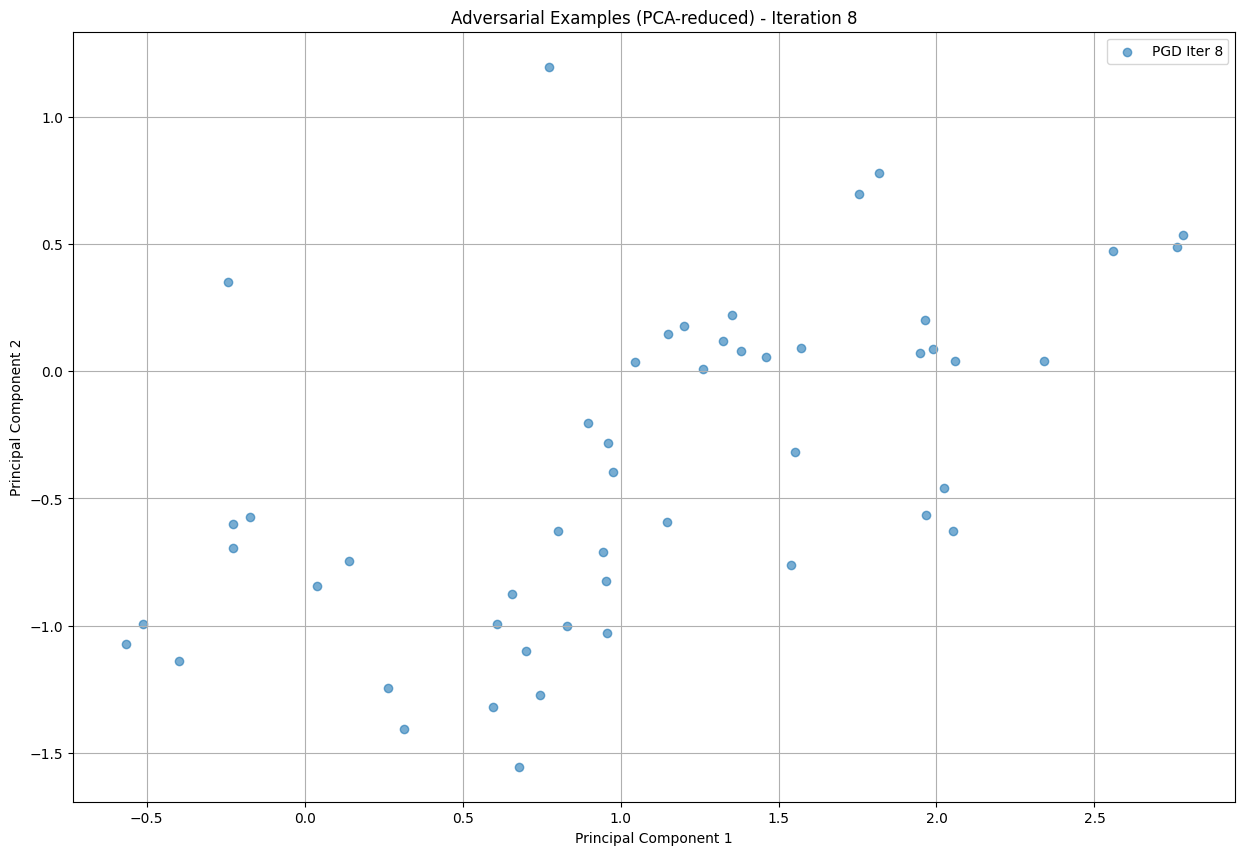

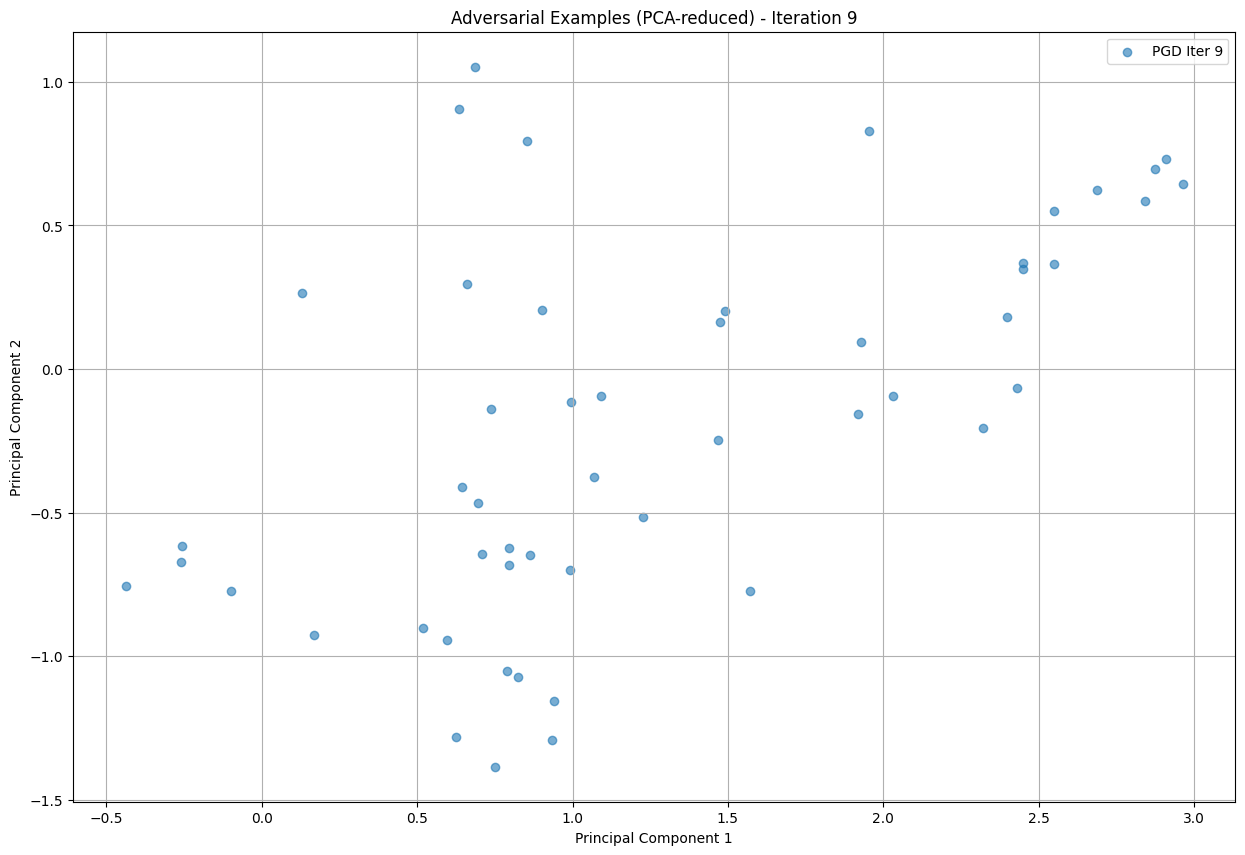

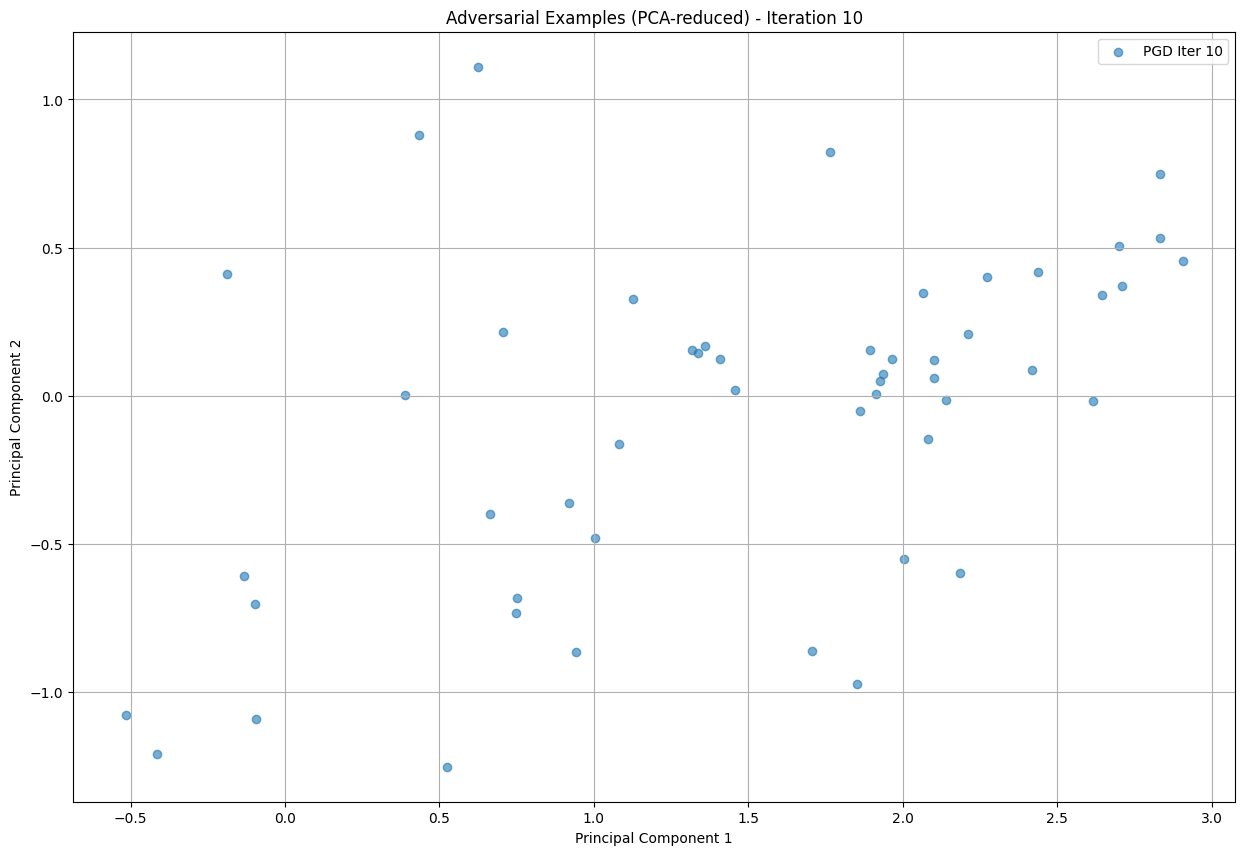

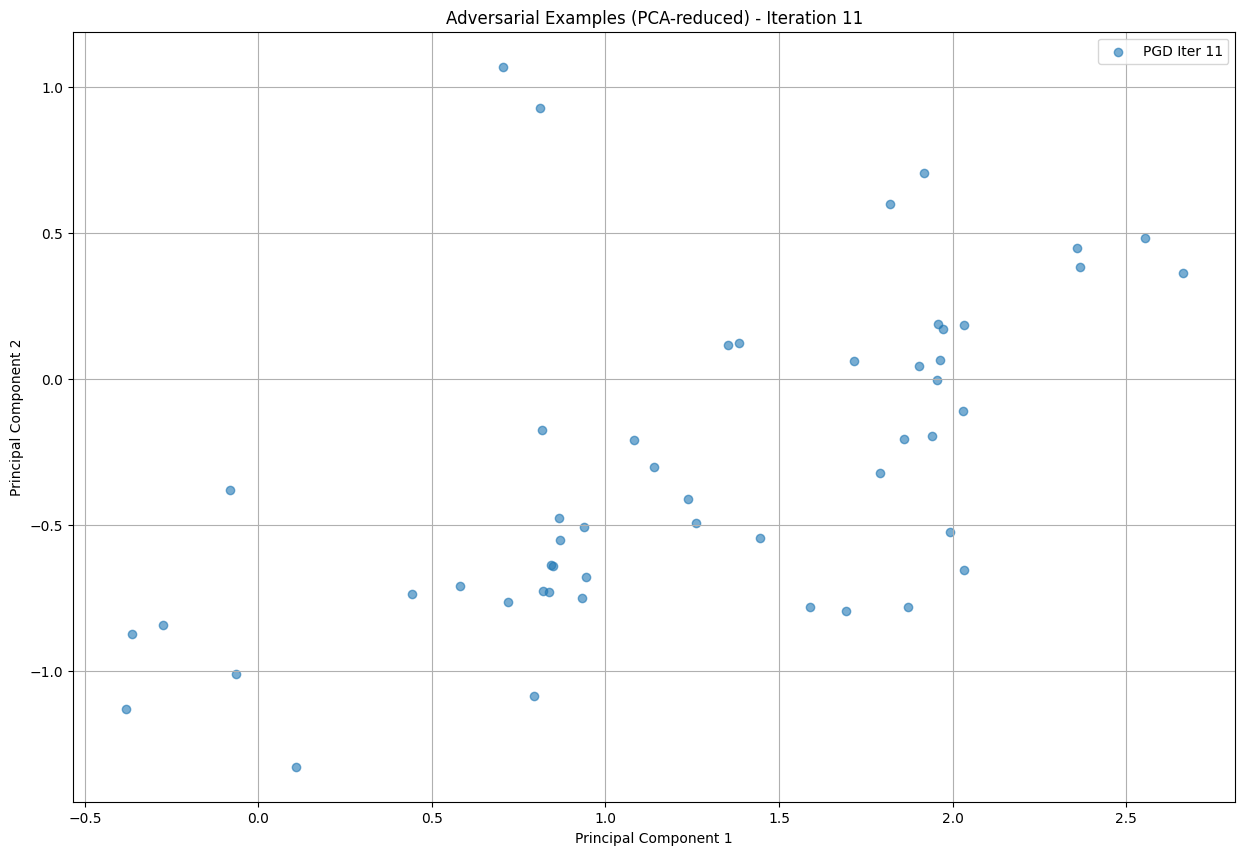

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')

# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize PGD attack
attack = ProjectedGradientDescent(estimator=classifier, eps=0.7, eps_step=0.1, max_iter=10)

# Perform PGD attack on the test set
X_test_adv = X_test.copy()

# Store the intermediate results
intermediate_results = []
accuracies = [accuracy_before_attack * 100]

# Initial accuracy
intermediate_results.append(X_test.copy())

# PGD attack iterations
for i in range(attack.max_iter):
    X_test_adv = attack.generate(X_test_adv)
    loss, accuracy = model.evaluate(X_test_adv, y_test, verbose=0)
    accuracies.append(accuracy * 100)
    intermediate_results.append(X_test_adv.copy())
    print(f"Iteration {i + 1}: Accuracy = {accuracy * 100:.2f}%")

# Plot model accuracy over PGD attack iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('PGD Attack Iterations')
plt.ylabel('Accuracy (%)')
plt.title('ANN Model Accuracy Over PGD Attack Iterations')
plt.grid(True)
plt.show()

# Confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before PGD Attack')
plt.show()

# Confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After PGD Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)
intermediate_results_pca = [pca.transform(X_adv) for X_adv in intermediate_results]

# Plot the adversarial examples for each iteration
for iteration, X_adv_pca in enumerate(intermediate_results_pca):
    plt.figure(figsize=(15, 10))
    plt.scatter(X_adv_pca[:, 0], X_adv_pca[:, 1], label=f'PGD Iter {iteration + 1}', alpha=0.6, cmap=plt.cm.Spectral)
    plt.title(f'Adversarial Examples (PCA-reduced) - Iteration {iteration + 1}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch 1/10
21/21 [==============================] - 0s 2ms/step - loss: 2.3064 - accuracy: 0.2090
Epoch 2/10
21/21 [==============================] - 0s 2ms/step - loss: 1.9084 - accuracy: 0.4627
Epoch 3/10
21/21 [==============================] - 0s 3ms/step - loss: 1.5124 - accuracy: 0.6667
Epoch 4/10
21/21 [==============================] - 0s 1ms/step - loss: 1.0944 - accuracy: 0.8408
Epoch 5/10
21/21 [==============================] - 0s 3ms/step - loss: 0.7380 - accuracy: 0.9154
Epoch 6/10
21/21 [==============================] - 0s 979us/step - loss: 0.4872 - accuracy: 0.9453
Epoch 7/10
21/21 [==============================] - 0s 4ms/step - loss: 0.3230 - accuracy: 0.9950
Epoch 8/10
21/21 [==============================] - 0s 953us/step - loss: 0.2260 - accuracy: 0.9900
Epoch 9/10
21/21 [==============================] - 0s 4ms/step - loss: 0.1682 - accuracy: 0.9801
Epoch 10/10
21/21 [==============================] - 0s 1ms/step - loss: 0.1236 - accuracy: 0.9950
Accuracy before

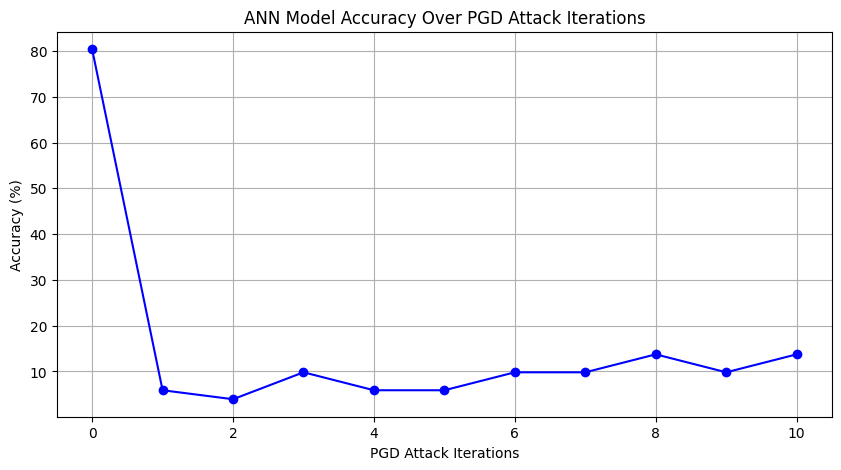

2/2 [==============================] - 0s 2ms/step


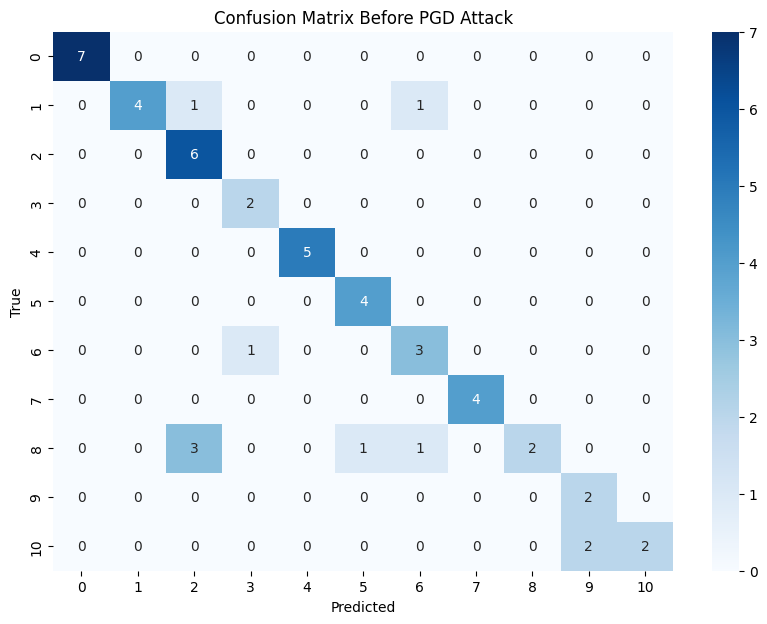

2/2 [==============================] - 0s 2ms/step


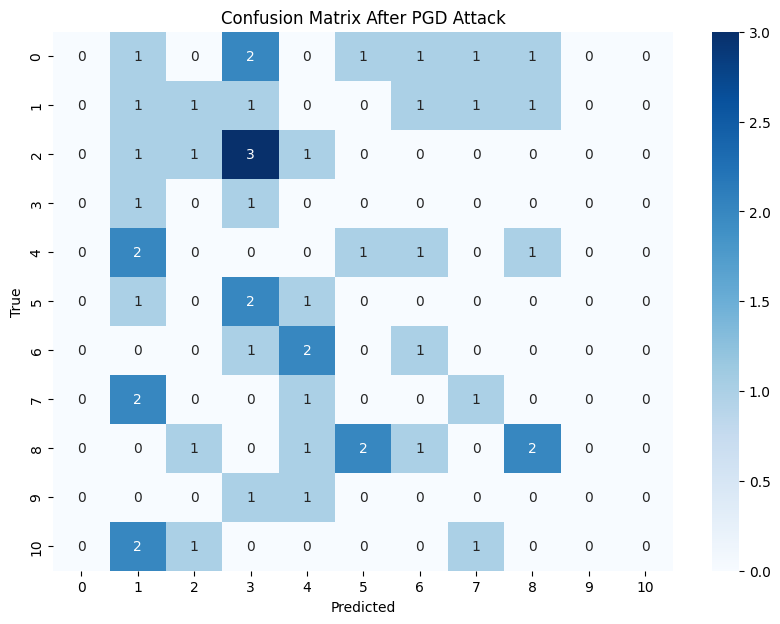

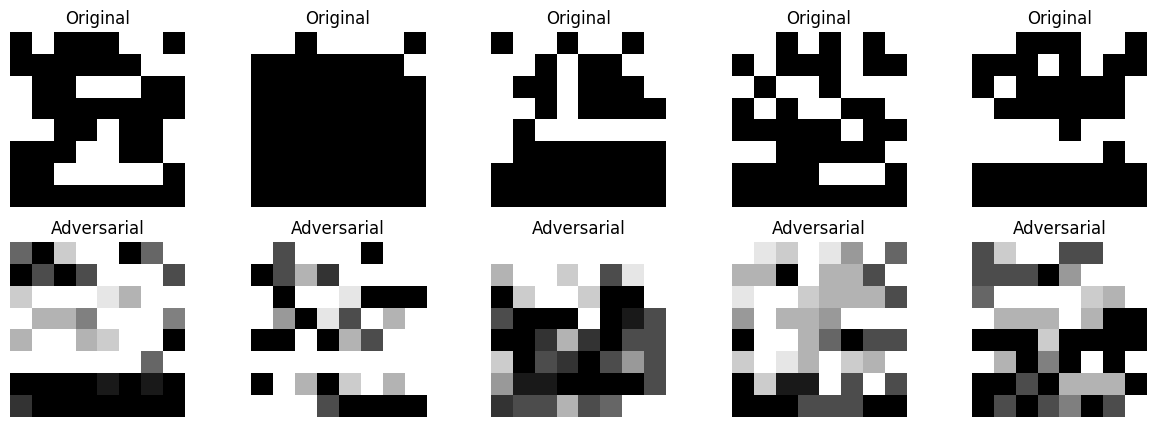

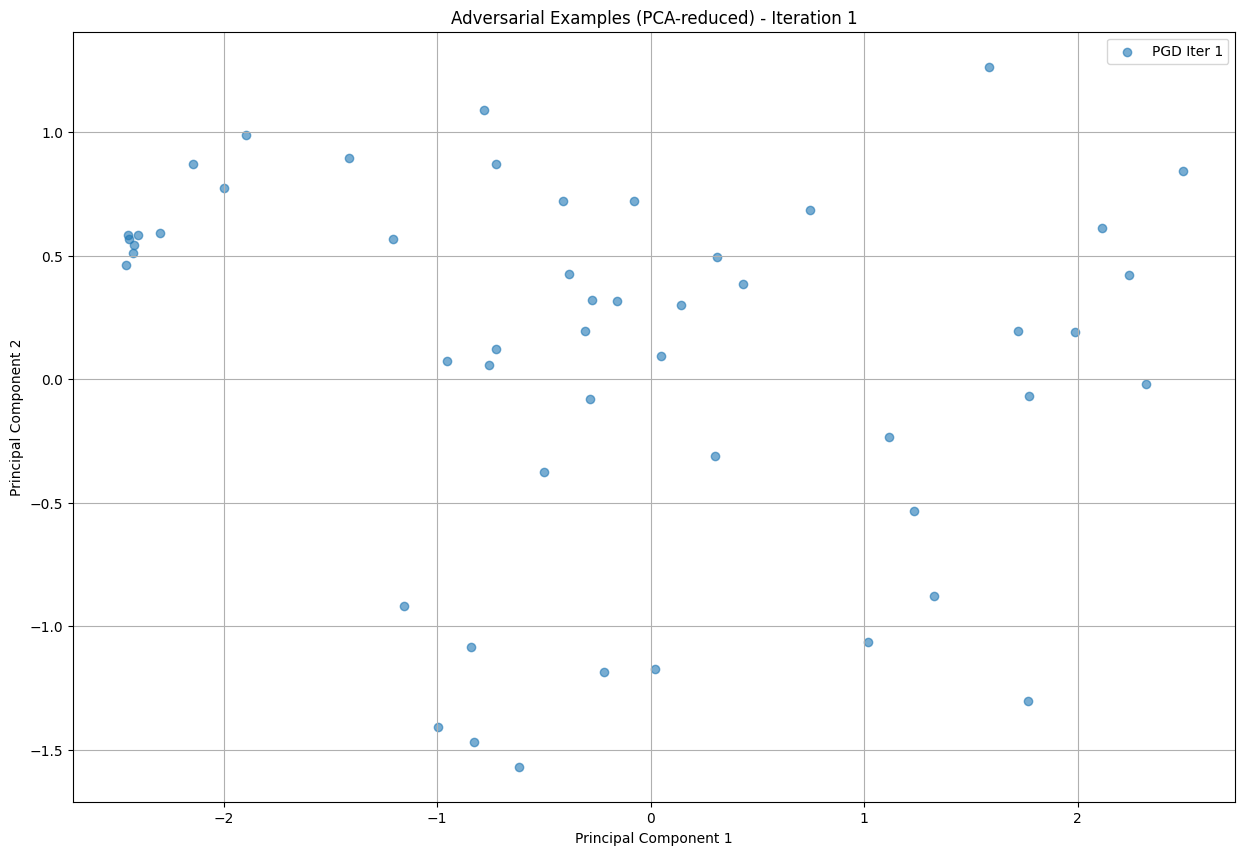

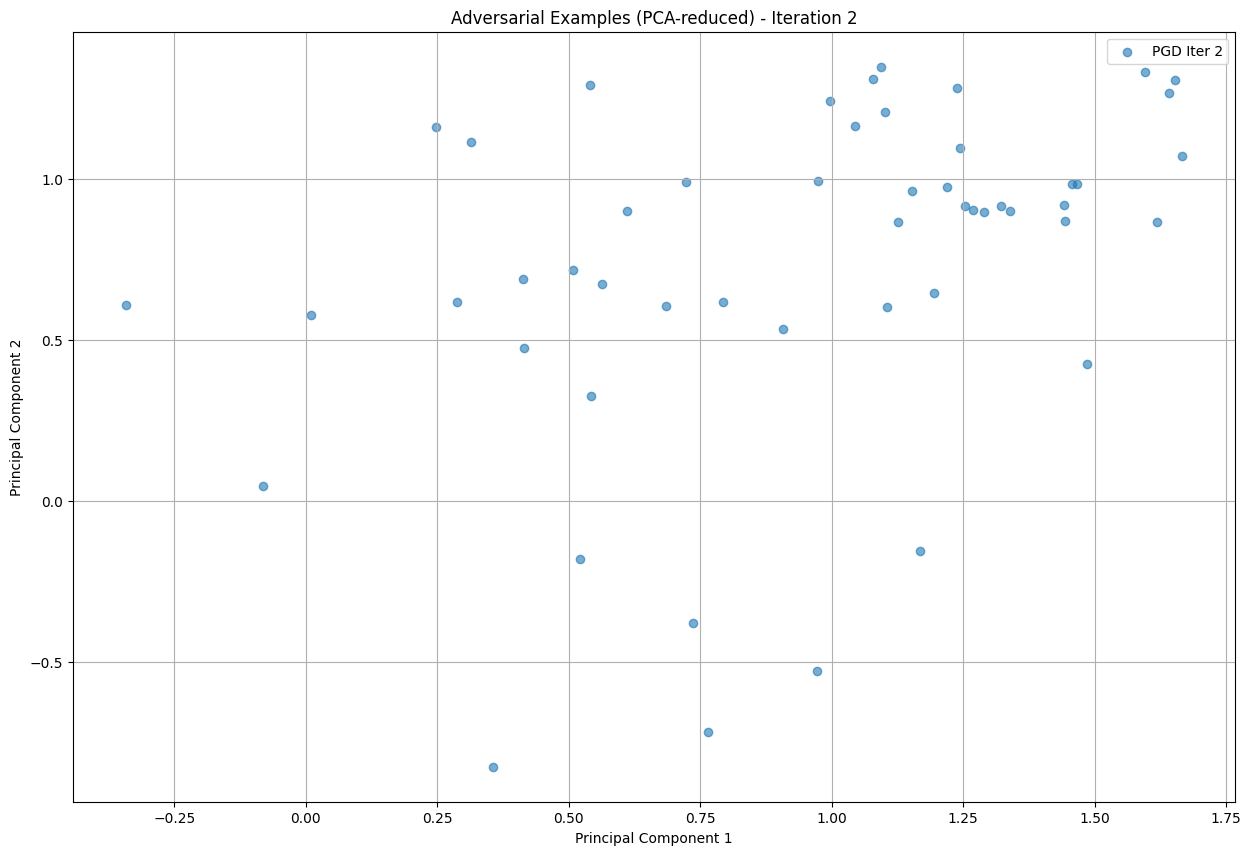

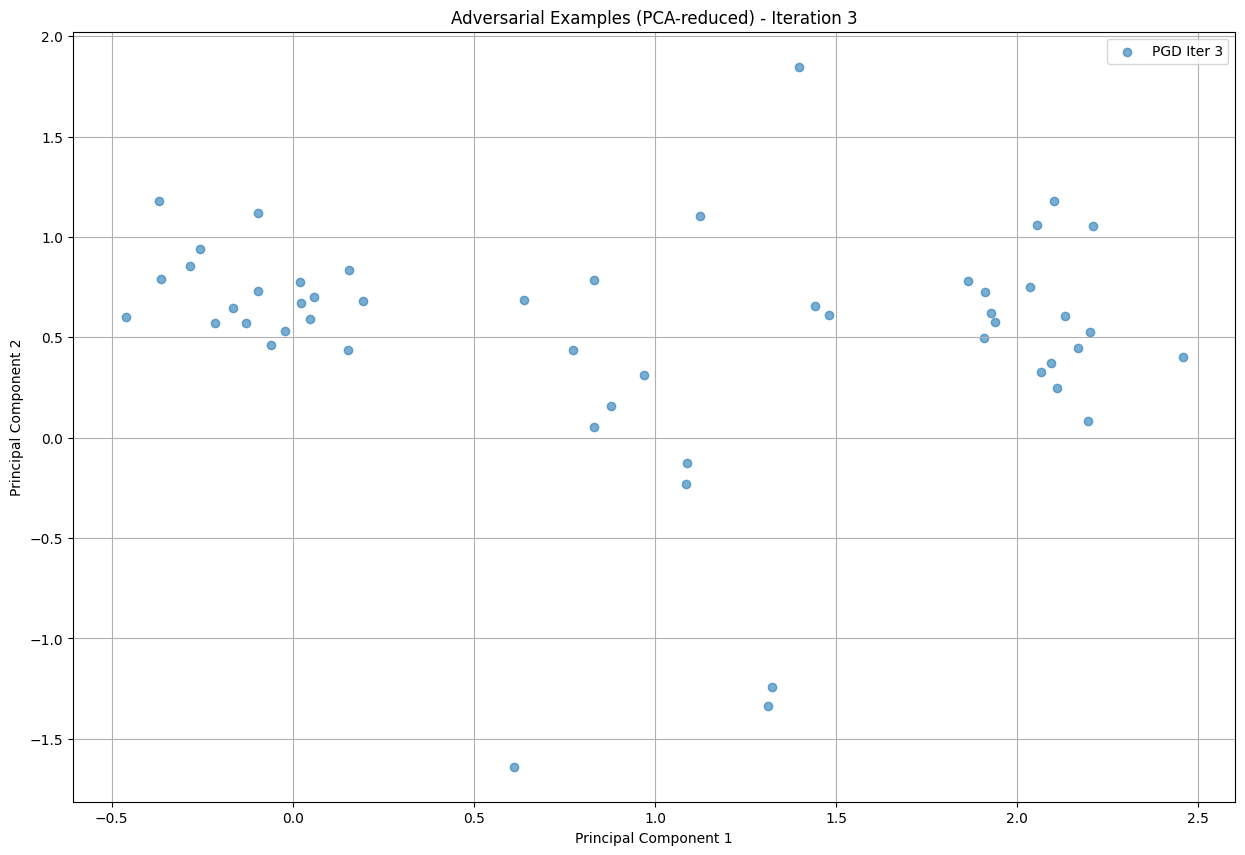

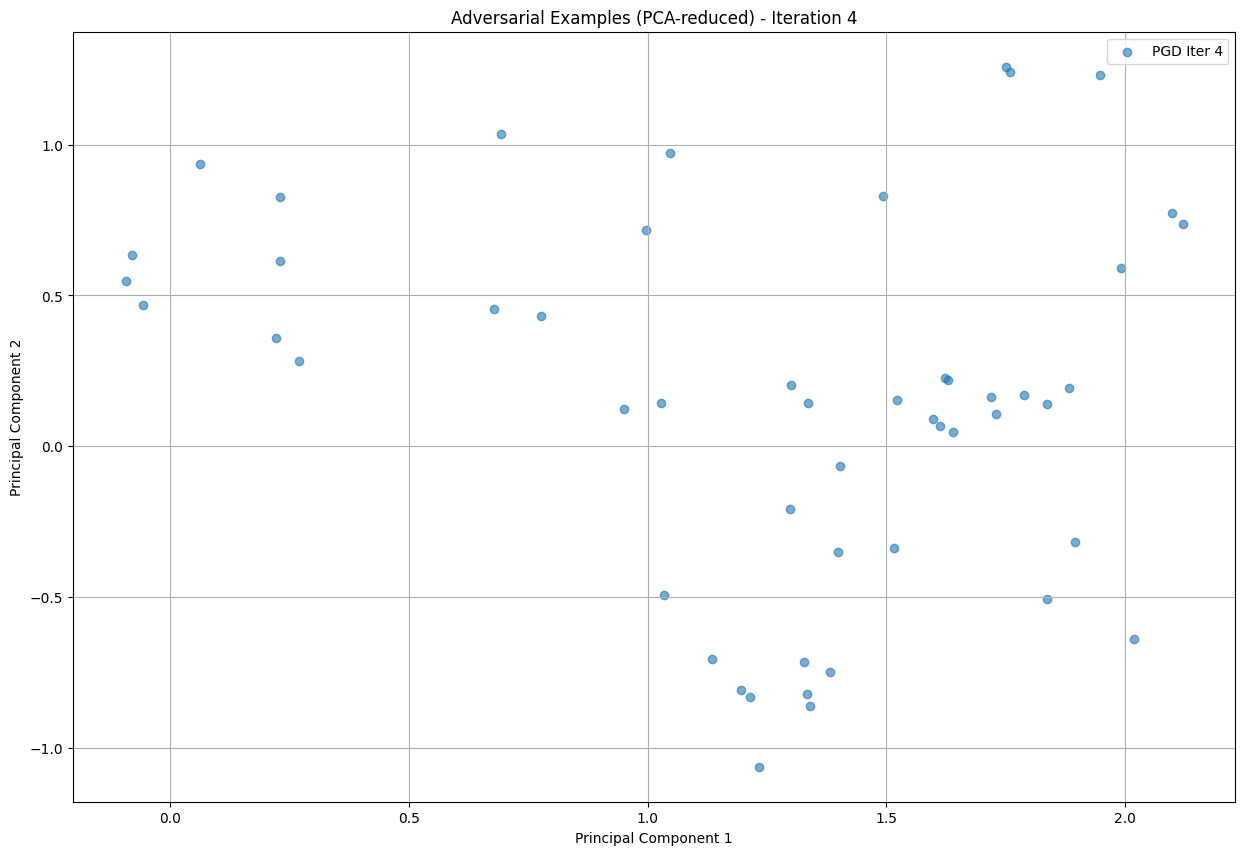

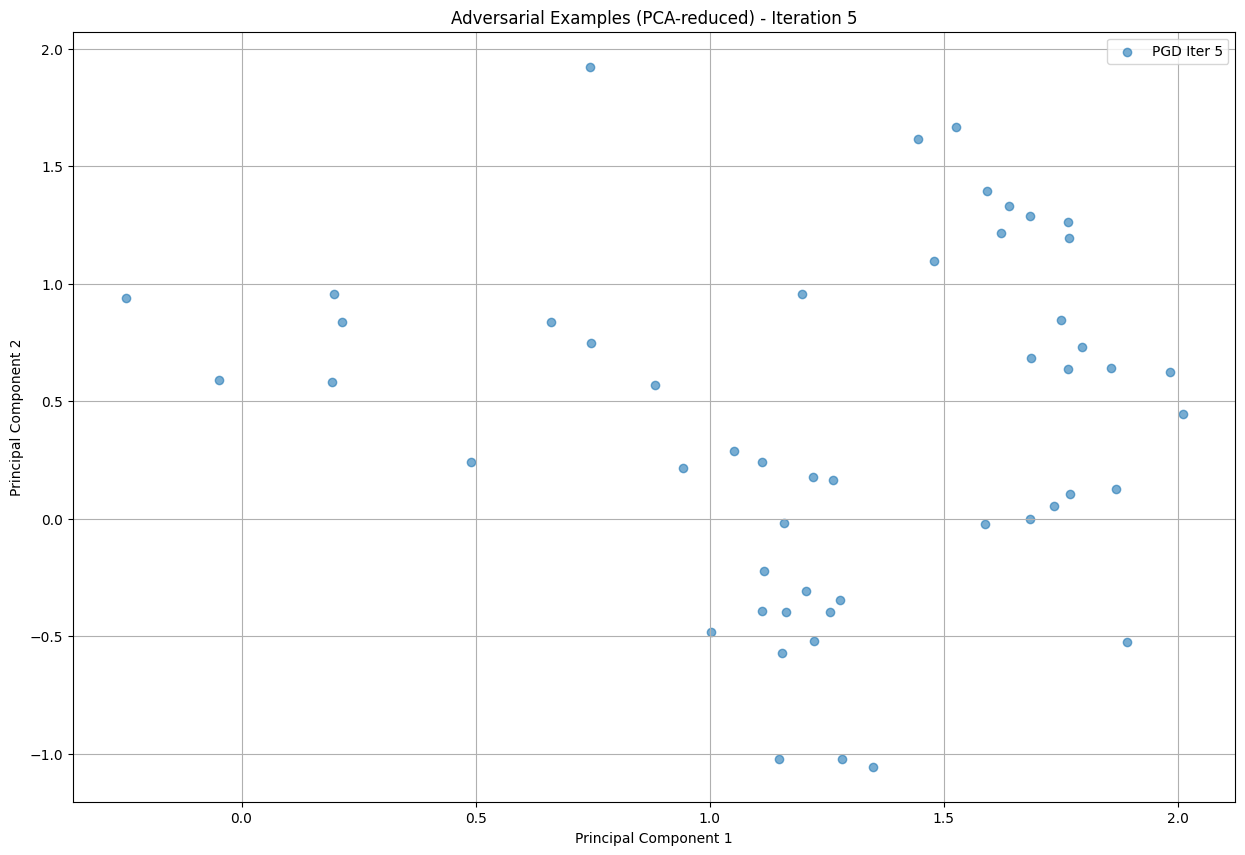

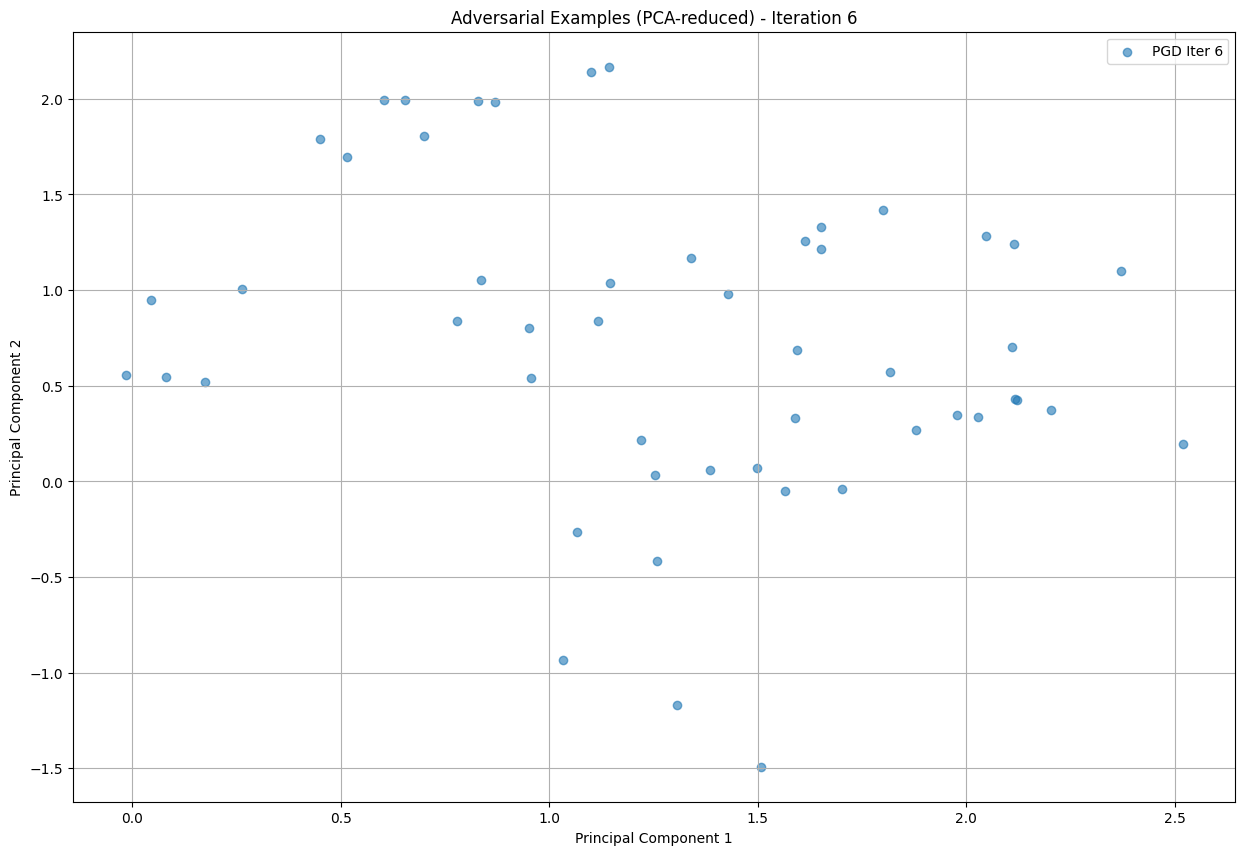

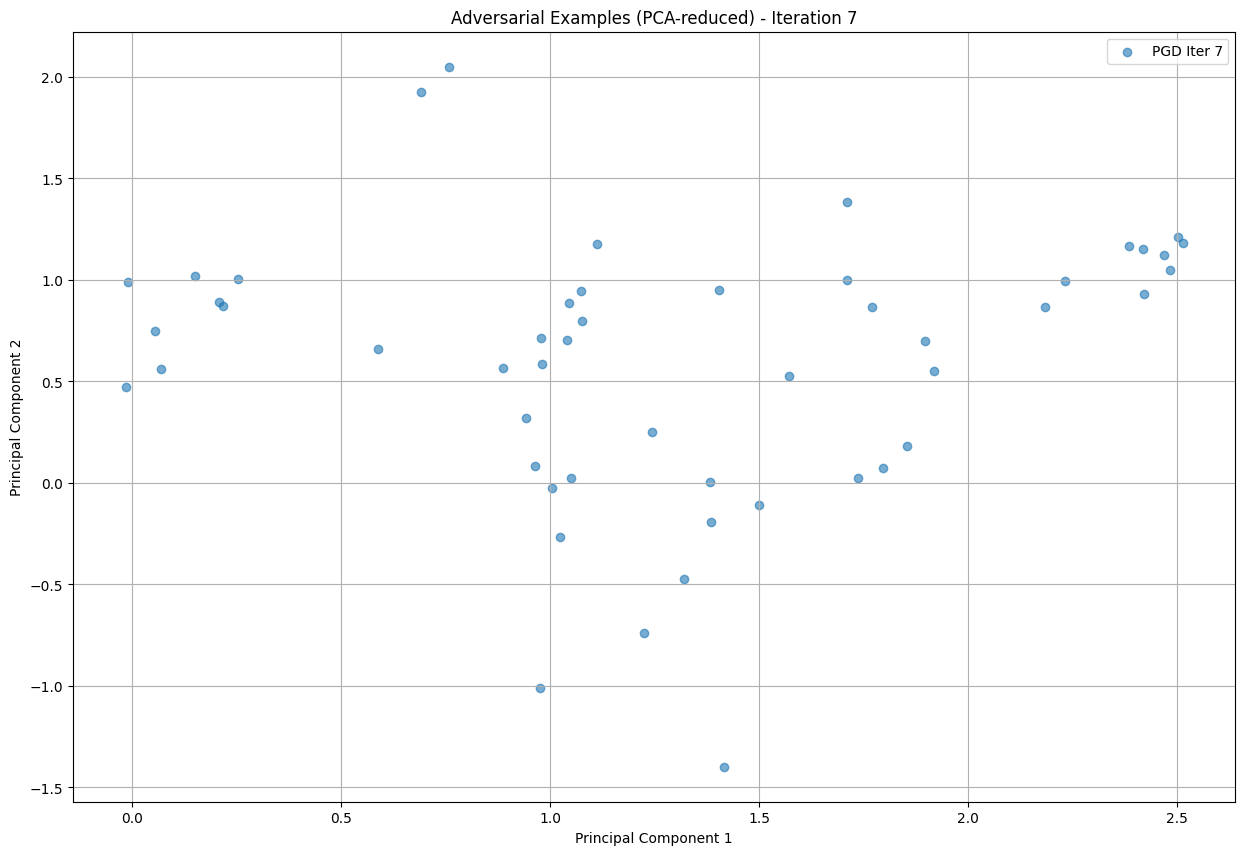

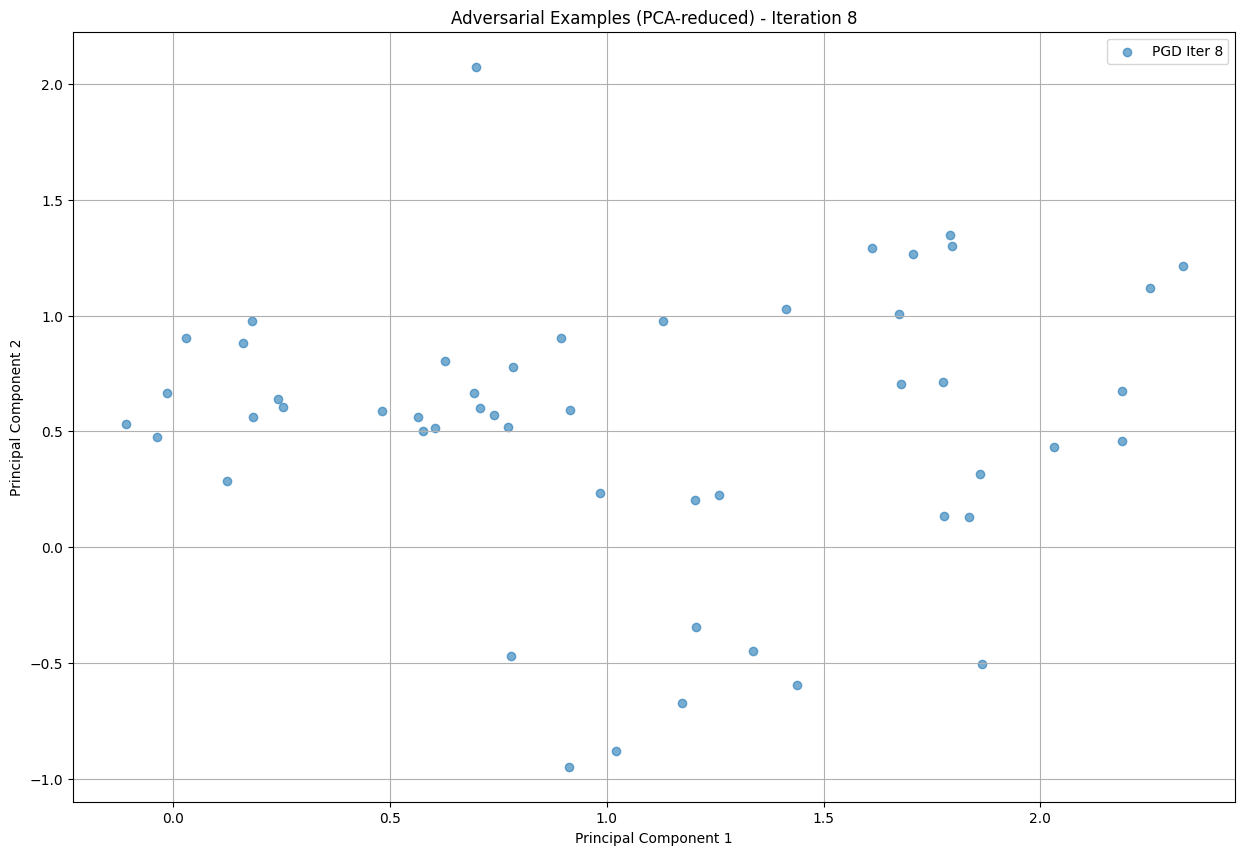

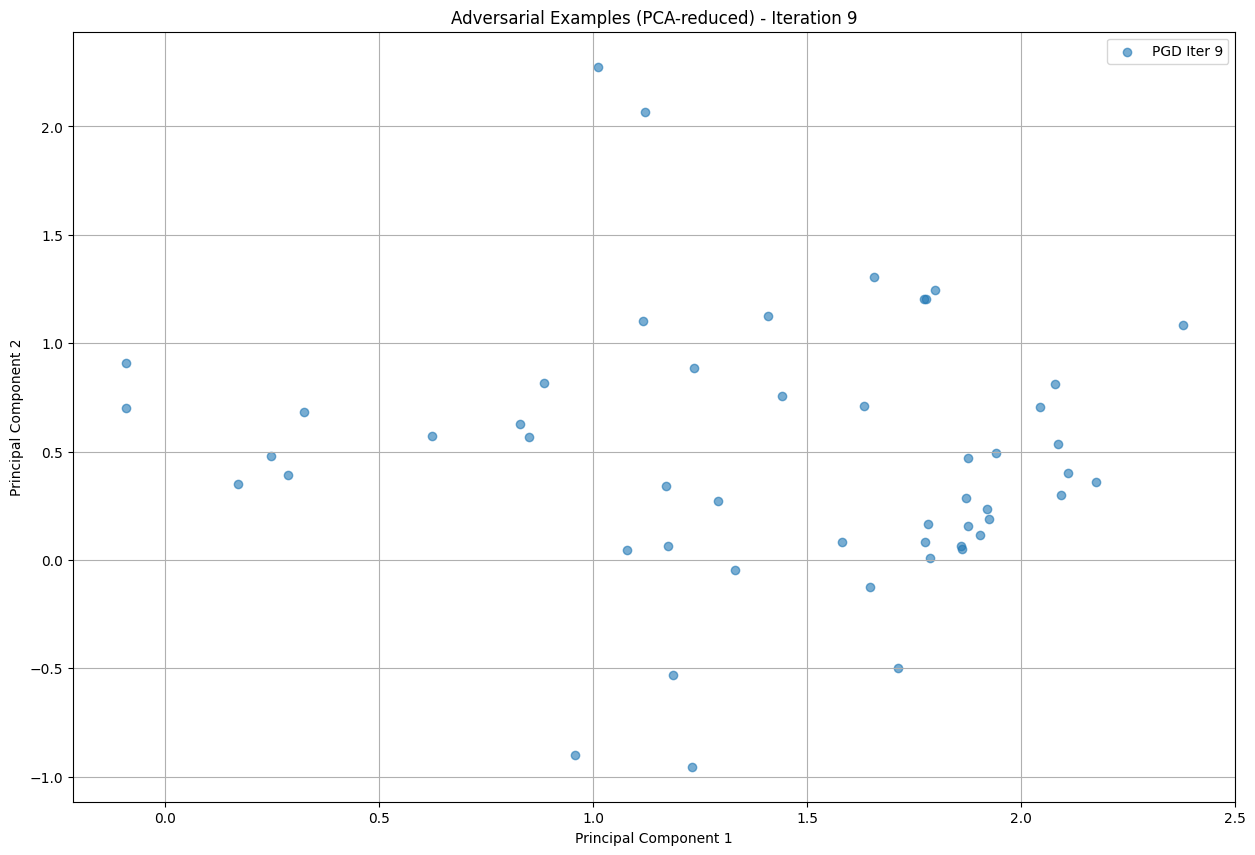

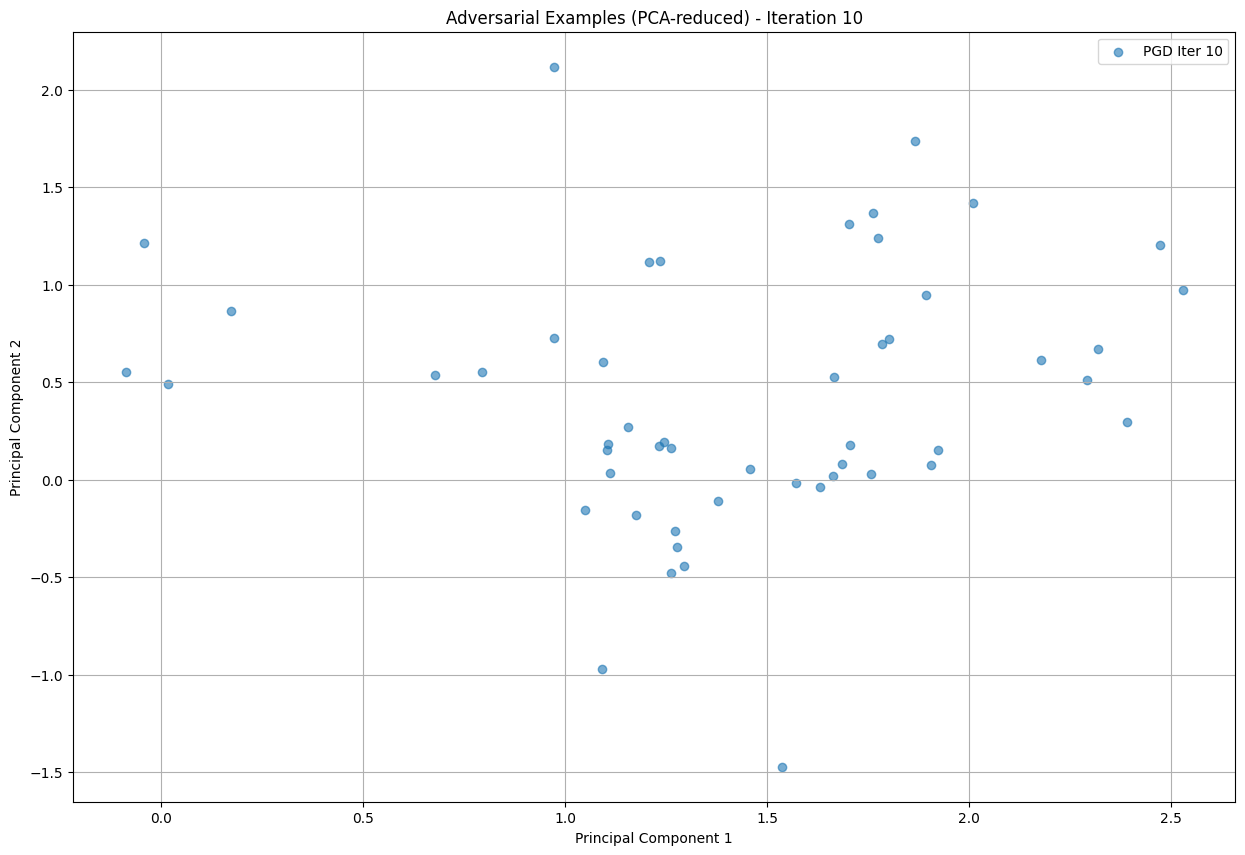

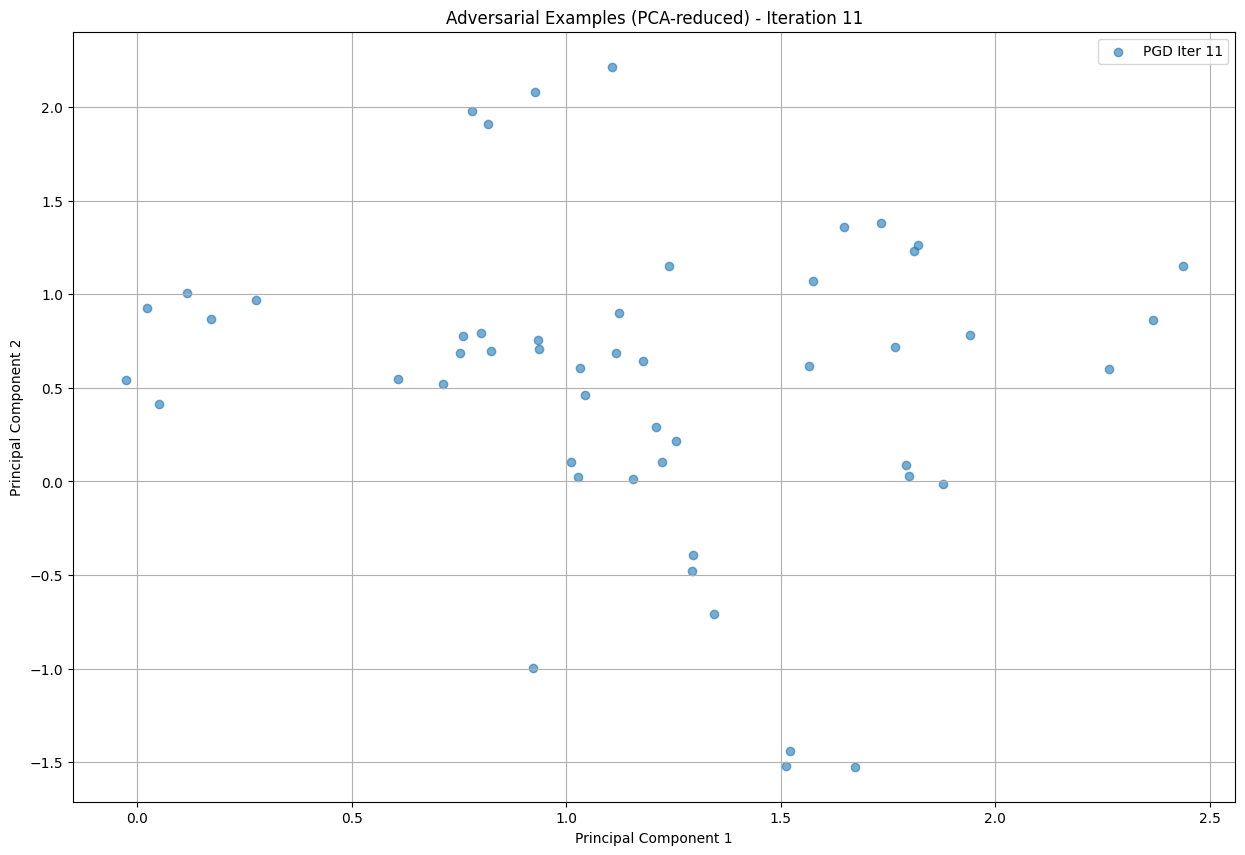

10512/10512 [==============================] - 10s 988us/step


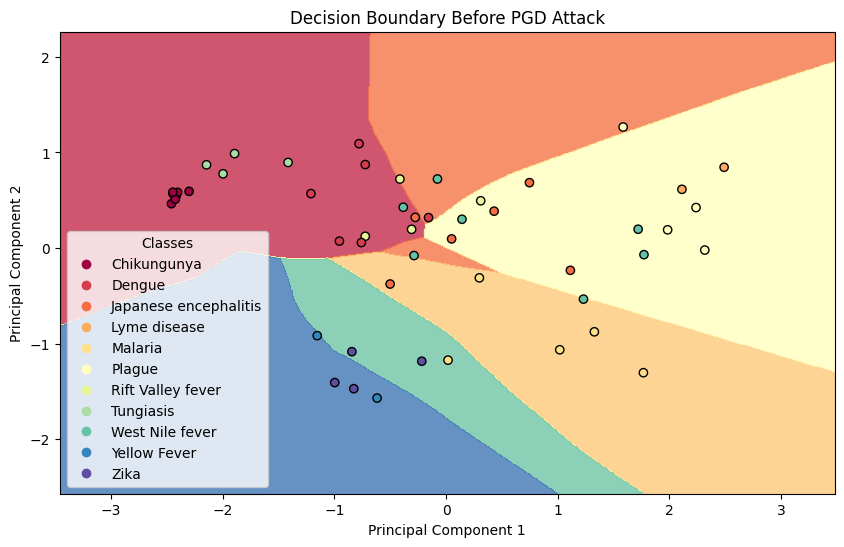

8019/8019 [==============================] - 8s 962us/step


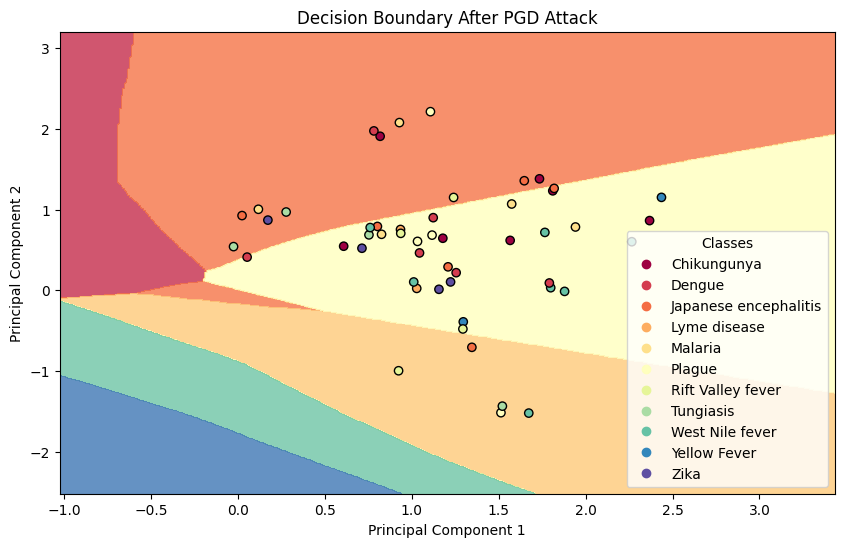

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import ProjectedGradientDescent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

# Load the dataset
train_df = pd.read_csv('/work/Downloaded/vbd-richard-bernat/trainn.csv')
test_df = pd.read_csv('/work/Downloaded/test.csv')


# Preprocess the data
# Encode target variable
le = LabelEncoder()
train_df['prognosis'] = le.fit_transform(train_df['prognosis'])
# Split into input (X) and output (y) variables
X = train_df.drop(['prognosis'], axis=1).values
y = train_df['prognosis'].values
y = to_categorical(y)  # Convert labels to one-hot encoding

# Define class labels
class_labels = [
    "Chikungunya", "Dengue", "Japanese encephalitis", "Lyme disease", 
    "Malaria", "Plague", "Rift Valley fever", "Tungiasis", 
    "West Nile fever", "Yellow Fever", "Zika"
]

# Split the dataset into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Define the Keras model
model = Sequential()
model.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))  # Ensure output layer matches the number of classes

# Compile the Keras model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Fit the Keras model on the dataset
model.fit(X_train, y_train, epochs=10, batch_size=10, verbose=1)

# Evaluate the model on the test set before attack
loss, accuracy_before_attack = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy before attack: {accuracy_before_attack*100:.2f}%")

# Wrap the model with ART's classifier
classifier = TensorFlowV2Classifier(
    model=model,
    nb_classes=y_train.shape[1],
    input_shape=(X_train.shape[1],),
    loss_object=tf.keras.losses.CategoricalCrossentropy(),
    clip_values=(np.min(X), np.max(X))
)

# Initialize PGD attack
attack = ProjectedGradientDescent(estimator=classifier, eps=0.7, eps_step=0.1, max_iter=10)

# Perform PGD attack on the test set
X_test_adv = X_test.copy()

# Store the intermediate results
intermediate_results = []
accuracies = [accuracy_before_attack * 100]

# Initial accuracy
intermediate_results.append(X_test.copy())

# PGD attack iterations
for i in range(attack.max_iter):
    X_test_adv = attack.generate(X_test_adv)
    loss, accuracy = model.evaluate(X_test_adv, y_test, verbose=0)
    accuracies.append(accuracy * 100)
    intermediate_results.append(X_test_adv.copy())
    print(f"Iteration {i + 1}: Accuracy = {accuracy * 100:.2f}%")

# Plot model accuracy over PGD attack iterations
plt.figure(figsize=(10, 5))
plt.plot(range(11), accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('PGD Attack Iterations')
plt.ylabel('Accuracy (%)')
plt.title('ANN Model Accuracy Over PGD Attack Iterations')
plt.grid(True)
plt.show()

# Confusion matrix before attack
y_pred_before = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm_before = confusion_matrix(y_true, y_pred_before)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Before PGD Attack')
plt.show()

# Confusion matrix after attack
y_pred_after = np.argmax(model.predict(X_test_adv), axis=1)

cm_after = confusion_matrix(y_true, y_pred_after)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix After PGD Attack')
plt.show()

# Visualize original vs adversarial values
num_samples = 5  # Number of samples to visualize
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(2, num_samples, i+1)
    plt.imshow(X_test[i].reshape((8, 8)), cmap='gray')  # Adjust the shape according to your data
    plt.title('Original')
    plt.axis('off')

    plt.subplot(2, num_samples, i+1+num_samples)
    plt.imshow(X_test_adv[i].reshape((8, 8)), cmap='gray')
    plt.title('Adversarial')
    plt.axis('off')
plt.show()

# Apply PCA for visualization
intermediate_results_pca = [pca.transform(X_adv) for X_adv in intermediate_results]

# Plot the adversarial examples for each iteration
for iteration, X_adv_pca in enumerate(intermediate_results_pca):
    plt.figure(figsize=(15, 10))
    plt.scatter(X_adv_pca[:, 0], X_adv_pca[:, 1], label=f'PGD Iter {iteration + 1}', alpha=0.6, cmap=plt.cm.Spectral)
    plt.title(f'Adversarial Examples (PCA-reduced) - Iteration {iteration + 1}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot decision boundaries before and after attack
def plot_decision_boundary(X, y, model, title, class_labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = np.argmax(model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])), axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y, axis=1), edgecolors='k', marker='o', cmap=plt.cm.Spectral)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    # Produce a legend with the unique colors from the scatter
    handles, labels = scatter.legend_elements(prop="colors")
    legend_labels = [class_labels[int(label)] for label in range(len(handles))]
    plt.legend(handles, legend_labels, title="Classes")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_test_pca, y_test, model, 'Decision Boundary Before PGD Attack', class_labels)
plot_decision_boundary(intermediate_results_pca[-1], y_test, model, 'Decision Boundary After PGD Attack', class_labels)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=82fc1969-7ff0-4344-a3e7-65ed95a291e5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>